# 🚀 Zach's Complete LLM Mastery — Master Notebook
## Neural Networks → PyTorch → Transformers → Pre-training → Fine-tuning → Alignment

> **13 lectures. One notebook. Zero hand-waving.**
> Every topic builds directly on the previous one. Start at Chapter 1 and work forward.

---

## 📋 Learning Path

```
Foundation                    Architecture              Production
────────────────────          ──────────────────        ─────────────────────
01 Neural Networks ──┐        04 Attention ──┐          08 Pre-Training ──┐
02 PyTorch ──────────┤        05 Transformer─┤          09 SFT ───────────┤
03 Adam ─────────────┘        06 KV Cache ───┤          10 LoRA ──────────┤
                              07 RoPE ────────┘         11 Quantization───┤
                                                        12 RLHF + PPO ────┤
                                                        13 DPO ────────────┘
```

| # | Chapter | Core Concept | Prerequisite |
|:--|:--|:--|:--|
| 🧠 01 | Neural Networks From Scratch | Gradient descent, backprop | None |
| 🔥 02 | PyTorch Deep Dive | Tensors, autograd, training loop | 01 |
| ⚡ 03 | Adam Optimizer | Adaptive learning rates, momentum | 02 |
| 👁️ 04 | Attention Mechanism | Scaled dot-product, Q/K/V | 02, 03 |
| 🤖 05 | Transformer From Scratch (GPT-2) | Full architecture | 04 |
| ⚡ 06 | KV Cache | Inference acceleration | 05 |
| 🌀 07 | RoPE | Positional encoding | 05 |
| 📚 08 | LLM Pre-Training | Data, tokenization, scaling laws | 05 |
| 💬 09 | SFT | Instruction tuning | 08 |
| 🪶 10 | LoRA | Parameter-efficient fine-tuning | 09 |
| 📦 11 | Quantization | INT8/INT4 compression | 02 |
| 🎯 12 | RLHF + PPO | Reward learning, policy optimization | 09 |
| 🏆 13 | DPO | Direct preference alignment | 12 |

---
> **Note:** Chapter 14 (Diffusion Models) is excluded — it's a separate track.


---

<br>

# ══════════════════════════════════════════════════════════════════════
# 🧠  Chapter 1: 01 · Neural Networks From Scratch
# ══════════════════════════════════════════════════════════════════════

> The building block of everything. Gradient descent, backprop, and the training loop — built with pure NumPy.

---

# 01. Neural Networks From Scratch: How AI Learns

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/The-Pocket/PocketFlow-Tutorial-Video-Generator/blob/main/docs/llm/01_Neural_Networks_From_Scratch.ipynb)

> **Tutorial Overview**: Master how neural networks learn from first principles. We will implement gradient descent, partial derivatives, the chain rule, and backpropagation from scratch in pure Python/NumPy, and visualize how the decision boundary evolves over time.
> **Original Source**: `nn.md`

---


In [2]:
# Setup & Imports
!pip install -q matplotlib numpy torch

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
print(" Setup complete! Pure NumPy & Matplotlib ready.")


zsh:1: command not found: pip
 Setup complete! Pure NumPy & Matplotlib ready.


# Give me 1 hour, You will MASTER how Neural Networks Learn
> You Learn Neural Networks WRONG

## Intro

You’ve seen the headlines. Artificial Intelligence is changing the world. At the heart of it all are "Neural Networks."

But how do they *actually learn*?

Maybe you've tried to figure this out before. You opened a book or watched a video, and within minutes, you were buried in jargon.

"Backpropagation!"
"Stochastic Gradient Descent!"
"Chain Rule!"
"Sigmoid Derivatives!"

It all feels like some impossibly complex black box. A machine that performs magic. You're told to just accept that it works.

Here's the truth: **You've been taught this the wrong way around.**

The core engine that powers all of modern AI is built on a few simple, incredibly intuitive ideas. And in this video, we are going to tear the whole process down and rebuild it together from the ground up.

*   How do you find your way to the bottom of a valley when you’re stuck in a thick fog?
*   How do you figure out who to "blame" when a team project goes wrong?

Once you grasp these simple ideas, the math suddenly makes perfect sense. It’s not a barrier; it's just the language we use to describe the logic you already understand.

Give me one hour. We will go step-by-step, with a full, transparent math walkthrough. No skipped steps. No magic. By the end of this video, you will have a deep, foundational understanding of how a machine truly learns. You won't just know the buzzwords; you will finally get the "Aha!" moment.

Ready to see behind the curtain? Let's begin.

## Part 1: Gradient Descent - Finding the Minimum

**THE SECRET:**


```text
INPUT: function f(x)
OUTPUT: argmin_x f(x)

FOR 100 iterations:
  gradient = f'(x)
  x = x - η × gradient
RETURN x
```


This algorithm is the beating heart of every AI system you've ever heard of. ChatGPT, image recognition, self-driving cars - they all use this exact loop to learn.

**Here's the thing:** Every neural network is trying to learn by minimizing its "error" - the difference between what it predicts and what's actually correct. This algorithm is the key process that guides the network toward perfection by systematically reducing that error.

**The intuition is simple:** Imagine you're lost in thick fog on a hill, trying to reach the valley floor. You can't see ahead, but you can feel the slope under your feet. So you repeatedly: (1) feel which way is steepest, (2) take a small step in the opposite direction (downhill), (3) repeat until the ground is flat.

That's exactly what our algorithm does mathematically.

#### **The Math Behind It**

Let's make this concrete with the function **f(x) = x²** - a perfect U-shaped valley.

The **gradient** (also called derivative) f'(x) tells us the slope at any point x. For our function: **f'(x) = 2x**

This means:
- At x=3: slope = 6 (steep uphill to the right)
- At x=-2: slope = -4 (steep uphill to the left)  
- At x=0: slope = 0 (perfectly flat - the minimum!)

Our update rule `x = x - η × f'(x)` automatically moves us opposite to the slope, toward the minimum.

#### **Step-by-Step Example**

**What we're minimizing:** f(x) = x² where x is the **independent variable** (we can control it) and f(x) is the **dependent variable** (depends on our choice of x).

Let's trace the algorithm starting at x₀ = 3 with learning rate η = 0.1:

| Iteration | Current x | f(x) = x² | Gradient f'(x) = 2x | Update: x - 0.1×f'(x) | New x |
|-----------|-----------|-----------|---------------------|----------------------|-------|
| 0 | 3.000 | **9.000** | 6.000 | 3.000 - 0.6 | **2.400** |
| 1 | 2.400 | **5.760** | 4.800 | 2.400 - 0.48 | **1.920** |
| 2 | 1.920 | **3.686** | 3.840 | 1.920 - 0.384 | **1.536** |
| 3 | 1.536 | **2.359** | 3.072 | 1.536 - 0.307 | **1.229** |
| 4 | 1.229 | **1.510** | 2.458 | 1.229 - 0.246 | **0.983** |
| ... | ... | ... | ... | ... | ... |
| 10 | 0.322 | **0.104** | 0.644 | 0.322 - 0.064 | **0.258** |

**What you'd see on the graph:**
- **Red dot** starts at (3, 9) on the parabola
- Each iteration: dot slides leftward down the curve
- **Blue tangent line** at each dot shows the slope
- Dot finally settles at (0, 0) - the bottom!

The algorithm discovers the minimum purely by following mathematical slopes. Brilliant!

#### **The Big Limitation: What About Bumpy Hills?**

Here's the catch: gradient descent has tunnel vision. It only sees the slope right under its feet.

**Example: A Function with a Trap**

Let's see this in action with f(x) = x⁴ - 4x² + x + 1. This creates a landscape with two valleys:

**(Scene: Show a curve with two dips - a shallow one on the left at x≈-1, and a deeper one on the right at x≈1.5)**

- **Local minimum** at x ≈ -1 (shallow valley, f(x) ≈ -1) 
- **Global minimum** at x ≈ 1.5 (deep valley, f(x) ≈ -2.8)

**What happens:**
- Start at x = -0.5 → Gradient descent gets trapped in the shallow valley at x ≈ -1
- Start at x = 0.5 → Finds the true deep valley at x ≈ 1.5

**On a smooth valley:** ✓ Finds the bottom perfectly
**On a jagged landscape:** ✗ Gets trapped wherever it starts

Same algorithm, different outcomes based on starting point!

**What about neural networks?**

Here's the surprising truth: large neural networks trained with gradient descent DO hit local minima, but they very rarely get trapped in bad ones.

**Why this works in practice:**
- **High dimensions are weird:** With millions of parameters, most "local minima" are actually good solutions
- **Many paths to success:** There are typically millions of different weight combinations that work well
- **Local minima cluster:** The "bad" local minima tend to be rare compared to the "good enough" ones

**The mystery:** We still don't fully understand why, but empirically, gradient descent finds excellent solutions for neural networks despite the theoretical trap problem. It's one of the luckiest coincidences in AI!

This is the core engine of ALL machine learning. Everything else is just calculating f'(x) for complex networks.

Up next, we'll see what happens when our valley has more than one dimension.


## Part 2: Partial Derivatives - The Multi-Dimensional Secret

**THE BREAKTHROUGH:**


```python
∂f/∂x = how steep in x-direction (treat y as constant)
∂f/∂y = how steep in y-direction (treat x as constant)
```


**The challenge:** Neural networks have millions of parameters. How do we figure out which direction to adjust each one? Partial derivatives let us calculate the effect of each parameter individually.

**Think of it like adjusting a soundboard - focus on one knob at a time while keeping everything else locked.**

#### **What Are Partial Derivatives?**

Remember gradients from Part 1? For f(x), we wrote f'(x) to get the slope. But what if our function depends on multiple variables?

Let's upgrade our simple valley. Instead of f(x) = x², consider:

**f(x1,x2) = x1² + 2x2²** 

This creates a 3D bowl-shaped valley. The minimum is at (0,0) where f(0,0) = 0.

Now we need TWO slopes:
- **∂f/∂x1:** How steep is the slope if we move in the x1-direction? 
- **∂f/∂x2:** How steep is the slope if we move in the x2-direction?

**The magic rule:** To find ∂f/∂x1, **TREAT x2 AS CONSTANT!!** (like it's just the number 5), then take the normal derivative with respect to x1.

**For our function f(x1,x2) = x1² + 2x2²:**
- ∂f/∂x1 = 2x1 (the 2x2² term disappears because x2 is "constant")
- ∂f/∂x2 = 4x2 (the x1² term disappears because x1 is "constant")

#### **Now The 2D Algorithm**

With partial derivatives understood, here's gradient descent for multiple variables:


```text
INPUT: function f(x1,x2), starting point (x1₀,x2₀)
OUTPUT: argmin_{x1,x2} f(x1,x2)

FOR 100 iterations:
  ∂f/∂x1 = calculate x1-gradient at current point
  ∂f/∂x2 = calculate x2-gradient at current point
  x1 = x1 - η × ∂f/∂x1
  x2 = x2 - η × ∂f/∂x2
RETURN (x1,x2)
```


Each variable gets its own update rule, but we apply them all simultaneously!

#### **Step-by-Step Example: 2D Gradient Descent**

**What we're minimizing:** f(x1,x2) = x1²+2x2² where (x1,x2) are the **independent variables** (we control them) and f(x1,x2) is the **dependent variable** (depends on our choices).

Let's trace the algorithm starting at (x1₀,x2₀) = (3,2) with η = 0.1:

| Iter | x1 | x2 | f(x1,x2)=x1²+2x2² | ∂f/∂x1=2x1 | ∂f/∂x2=4x2 | x1-η×∂f/∂x1 | x2-η×∂f/∂x2 | New (x1,x2) |
|------|---|---|------------|----------|----------|-----------|-----------|-----------|
| 0 | 3.00 | 2.00 | **17.00** | 6.00 | 8.00 | 3.00-0.6 | 2.00-0.8 | **(2.40, 1.20)** |
| 1 | 2.40 | 1.20 | **8.64** | 4.80 | 4.80 | 2.40-0.48 | 1.20-0.48 | **(1.92, 0.72)** |
| 2 | 1.92 | 0.72 | **4.72** | 3.84 | 2.88 | 1.92-0.384 | 0.72-0.288 | **(1.54, 0.43)** |
| 3 | 1.54 | 0.43 | **2.74** | 3.08 | 1.72 | 1.54-0.308 | 0.43-0.172 | **(1.23, 0.26)** |
| ... | ... | ... | ... | ... | ... | ... | ... | ... |
| 10 | 0.40 | 0.03 | **0.162** | 0.80 | 0.12 | 0.40-0.08 | 0.03-0.012 | **(0.32, 0.018)** |

**What you'd see on the graph:**
- **Red dot** starts at (3,2,17) on the bowl surface [since f(3,2) = 9+8 = 17]
- Each iteration: dot slides toward center (0,0,0) 
- **Two gradient arrows** at each point show the x-slope and y-slope
- Dot spirals down to the bottom at (0,0,0)

Both x and y converge toward 0 simultaneously! The algorithm finds the minimum of our 2D bowl automatically.

This is the fundamental technique we use to update every single weight in a neural network. We calculate each weight's individual contribution to the total error using partial derivatives, then nudge each weight in the right direction.

The magic: each variable gets its own gradient, but they all work together to find the minimum. Scale this up to millions of variables, and you have neural network training!


## Part 3: Chain Rule - The Backpropagation Secret

**THE MASTERSTROKE:**


```text
dy/dx = (dy/du) × (du/dx)
```


This elegant formula is what makes deep learning possible. It traces influence through chains of cause-and-effect, no matter how long the chain gets.

**The problem it solves:** In deep networks, a weight might be 20 layers away from the final error. How do you calculate its responsibility? The Chain Rule multiplies the influence at each step to find the total impact.

**Here's the beautiful part - it works exactly like playing the "blame game" to find who's responsible for a problem.**

**The Blame Game Analogy:** Imagine your team project failed. You need to trace back:
- The final presentation was bad (the error)
- Because the slides were wrong (intermediate step)  
- Because the data analysis was flawed (earlier step)
- Because the original data collection was sloppy (root cause)

To find how much the data collector is to blame for the final failure, you multiply the blame at each step: data → analysis → slides → presentation.

**Chain Rule does exactly this:** It traces responsibility backward through nested functions to find how much each variable contributes to the final result.

#### **A Complex Function with Multiple Variables**

Imagine we have this intimidating nested function with multiple variables:

**f(x1,x2) = ((2x1 + x2)² + 3x2²)³**

This looks complex! Multiple variables AND nested operations. Let's break it down into a chain:
- Let u = 2x1 + x2
- Let v = u² + 3x2²  
- Then f = v³

So we have: (x1,x2) → u → v → f

**So many variables and steps! But don't worry - the chain rule makes this easy to compute:**

We need both ∂f/∂x1 and ∂f/∂x2. Let's use the chain rule:

**For ∂f/∂x1:**
∂f/∂x1 = (∂f/∂v) × (∂v/∂u) × (∂u/∂x1)

- ∂u/∂x1 = 2 (derivative of 2x1 + x2 with respect to x1)
- ∂v/∂u = 2u (derivative of u² + 3x2² with respect to u)  
- ∂f/∂v = 3v² (derivative of v³)

Therefore: **∂f/∂x1 = 3v² × 2u × 2 = 12uv²**

**For ∂f/∂x2:**
∂f/∂x2 = (∂f/∂v) × (∂v/∂x2)

- ∂v/∂x2 = ∂u/∂x1 × ∂u/∂x2 + ∂(3x2²)/∂x2 = 2u × 1 + 6x2 = 2u + 6x2
- ∂f/∂v = 3v² (same as before)

Therefore: **∂f/∂x2 = 3v² × (2u + 6x2)**

#### **Chain Rule Makes Complex Functions Tractable**

**What we're minimizing:** f(x1,x2) = ((2x1 + x2)² + 3x2²)³ where (x1,x2) are the **independent variables** (we control them) and f(x1,x2) is the **dependent variable** (result of our choices).

Now here's the magic: we can use both gradients in our multi-variable gradient descent algorithm!


```text
FOR 100 iterations:
  ∂f/∂x1 = 12uv² 
  ∂f/∂x2 = 3v²(2u + 6x2)
  x1 = x1 - η × ∂f/∂x1
  x2 = x2 - η × ∂f/∂x2
RETURN (x1,x2)
```


The chain rule lets us find gradients for arbitrarily complex nested functions with multiple variables. Combined with gradient descent, we can minimize even the most intimidating functions!

**The power of this approach:** No matter how complex your function gets - deeply nested, multiple variables - you can always:
1. Use the chain rule to find all partial derivatives
2. Apply gradient descent to minimize it

This systematic approach works for ANY differentiable function. Now you can handle functions with millions of variables and thousands of nested operations!

## Part 4: Forward Pass - Building Our First Neural Network

#### **What's a Neural Network?**

A neural network is just a collection of simple functions (called "neurons") organized in "layers." Each neuron takes some inputs, does a simple calculation, and passes the result to the next layer.

**Neurons:** Each neuron is just a simple function - like f(x,y) = (x + 2y)² or g(a,b) = 3ab. Nothing magical!

**Layers:** We organize neurons into layers because of **dependencies**. Think of it like cooking:
- **Layer 1 neurons:** Use the raw ingredients (inputs x1, x2)
- **Layer 2 neurons:** Use the results from Layer 1 (can't compute until Layer 1 is done)
- **Layer 3 neurons:** Use the results from Layer 2, and so on...

This creates a **forward flow**: Raw data → Layer 1 → Layer 2 → Final answer

**Why layers matter:** Each layer must finish its calculations before the next layer can start. It's like an assembly line where each station depends on the previous one.

Let's build a neural network with interesting nested functions. It will have:
- **2 inputs** (x1, x2)
- **2 neurons in Layer 1** 
- **1 neuron in Layer 2**
- **5 weights to learn** (w1, w2, w3, w4, w5)

This is called the **Forward Pass** - the network reads inputs and produces a prediction. No learning yet, just calculating an output.

#### **The Network Architecture**

Each neuron is just a nested function:


```python
Layer 1:
  neuron 1: h1 = (x1 + w1*x2)²
  neuron 2: h2 = w2*x1*x2

Layer 2:
  neuron 1: y_pred = w3*h1 + w4*h2 + w5
```


**Our Task:** Train the network to learn this target function: f(x1,x2) = 2x1² + 3x2

Here are our 3 training examples:

| Input (x1,x2) | y_true | What We Want |
|-------------|---------------|--------------|
| (3, 2) | 2(3²) + 3(2) = 18 + 6 = **24** | Network should output 24 |
| (1, 4) | 2(1²) + 3(4) = 2 + 12 = **14** | Network should output 14 |
| (2, 1) | 2(2²) + 3(1) = 8 + 3 = **11** | Network should output 11 |

Let's see how our network does on all examples:

**Initial weights:** w1=1, w2=2, w3=1, w4=1, w5=0

#### **Network Results**

| Input (x1,x2) | y_true | Network Predicts | Difference |
|-------------|----------|------------------|------------|
| (3, 2) | 24 | 37 | -13 |
| (1, 4) | 14 | 33 | -19 |
| (2, 1) | 11 | 13 | -2 |

#### **Let's quantify the error!**

**How do we measure success?** We need a single number that tells us how wrong our network is across all examples.

**Why not just add up the differences?** (-13) + (-19) + (-2) = -34. But what if we had differences of +17 and -17? They'd cancel out to 0, making the network look perfect when it's actually terrible!

**Solution: Square the differences!** (difference)² is always positive, and bigger mistakes get penalized more:
- Small mistake: (-2)² = 4  
- Big mistake: (-19)² = 361

**Total Squared Error:**
Error = (-13)² + (-19)² + (-2)² = 169 + 361 + 4 = **534**

Our network is way off! It should learn f(x1,x2) = 2x1² + 3x2, but it's computing something completely different. The large total error shows this network desperately needs training.

We have successfully completed the Forward Pass. Our network made a prediction and we measured how wrong it was.

Next, we'll use the tools from Parts 1-3 to fix this terrible prediction. We'll trace the error backward through all the complex nested operations (chain rule) to find how much each weight contributed (partial derivatives), then adjust all weights to reduce the error (gradient descent).

## Part 5: Backpropagation - How Neural Networks Learn

#### **Key Insight: Neural Networks ARE Nested Functions**

Remember from Part 3 how we handled complex nested functions? Neural networks are exactly the same thing!

**Side-by-side comparison:**

| Complex Functions (Part 3) | Neural Networks (Part 4) |
|----------------------------|---------------------------|
| Nested operations: f(g(h(x))) | Layered operations: Layer2(Layer1(inputs)) |
| Variables: x1, x2 | Variables: ??? |
| Goal: Minimize f(x1,x2) | Goal: Minimize Error(???) |
| Tool: Chain rule + Gradient descent | Tool: Chain rule + Gradient descent |

**Question: What are the variables in our neural network?**

Let's see what we have:
- 2 inputs (x1, x2)
- 2 neurons in Layer 1  
- 1 neuron in Layer 2
- 5 weights to learn (w1, w2, w3, w4, w5)

**Answer:** x1, x2? **WRONG!** 

The inputs (x1, x2) are **given** to us in the training data. We can't change them.

**The variables we control are the weights:** w1, w2, w3, w4, w5

**Updated comparison:**

| Complex Functions (Part 3) | Neural Networks (Part 4) |
|----------------------------|---------------------------|
| Variables: x1, x2 | Variables: w1, w2, w3, w4, w5 |
| Goal: Minimize f(x1,x2) | Goal: Minimize Error(w1,w2,w3,w4,w5) |

**The breakthrough:** We already know how to minimize complex nested functions! Neural networks are just another nested function - same tools, same approach.

We use gradient descent to find the weights that minimize the error, just like we found x1,x2 values that minimized functions in Parts 1-3!

Time to play the "blame game" we learned in Part 3! We'll trace backward from the error to find how much each weight is responsible for the mistake.

#### **The Network Architecture**

Let's recap our network with our example: x1=3, x2=2, y_true=24, prediction=37.


```text
Layer 1:
  Input:
    constant: x1, x2
    variable: w1, w2
  Output:
    neuron 1: h1 = (x1 + w1×x2)² = (3 + 1×2)² = 25
    neuron 2: h2 = w2×x1×x2 = 2×3×2 = 12

Layer 2:
  Input:
    variable: h1, h2, w3, w4, w5
  Output:
    neuron 1: y_pred = w3×h1 + w4×h2 + w5 = 1×25 + 1×12 + 0 = 37

Error:
  Input:
    constant: y_true = 24
    variable: y_pred = 37
  Output:
    Error = (y_true - y_pred)² = (24 - 37)² = 169
```


Think of this like a blame investigation. Our prediction was wrong (Error = 169), and we need to figure out which weights are most responsible for this mistake.

#### **Starting Simple: w5**

Let's start with the simplest case. How much is w5 to blame?

w5's path to the error is direct: Error ← y_pred ← w5

To find how changing w5 affects the error, we use the chain rule:
∂Error/∂w5 = ∂Error/∂y_pred × ∂y_pred/∂w5

Let's calculate each piece:
- ∂Error/∂y_pred = ∂/∂y_pred [(y_true - y_pred)²] = 2×(y_pred - y_true) = 2×(37 - 24) = **26**
- ∂y_pred/∂w5 = ∂/∂w5 [w3×h1 + w4×h2 + w5] = **1**

Therefore: **∂Error/∂w5 = 26 × 1 = 26**

#### **Adding Complexity: w1**

Now let's try a trickier weight. How much is w1 to blame?

w1's path to the error is longer: Error ← y_pred ← h1 ← w1

Using the chain rule:
∂Error/∂w1 = ∂Error/∂y_pred × ∂y_pred/∂h1 × ∂h1/∂w1

We already know ∂Error/∂y_pred = 26. Let's find the other pieces:
- ∂y_pred/∂h1 = ∂/∂h1 [w3×h1 + w4×h2 + w5] = w3 = **1**
- ∂h1/∂w1 = ∂/∂w1 [(x1 + w1×x2)²] = 2×(x1 + w1×x2)×x2 = 2×(3 + 1×2)×2 = **20**

Therefore: **∂Error/∂w1 = 26 × 1 × 20 = 520**

#### **The Pattern: Look at the Overlap!**

Let's write out the full formulas we just calculated:


```text
∂Error/∂w5 = ∂Error/∂y_pred × ∂y_pred/∂w5 = 26 × 1 = 26

∂Error/∂w1 = ∂Error/∂y_pred × ∂y_pred/∂h1 × ∂h1/∂w1 = 26 × 1 × 20 = 520
```


Wait! Notice that **∂Error/∂y_pred = 26** appears in both calculations! 

**Key insight!!** These intermediate computations are shared! Every weight's gradient includes ∂Error/∂y_pred. This means we can:

1. **Compute once**: Calculate ∂Error/∂y_pred = 26
2. **Reuse everywhere**: Use this value for all weight gradients
3. **Propagate backward**: Work layer by layer, reusing computations

This is the essence of backpropagation - we propagate the error gradient backward through the network, reusing shared computations!

#### **Systematic Approach: All Weights at Once**

Now let's systematically compute all weight gradients using our shared computation:

First, we compute all the individual derivatives we need:


```text
Error gradients:
  ∂Error/∂y_pred = 26

Layer 2 gradients:
  ∂y_pred/∂w5 = 1
  ∂y_pred/∂w4 = h2 = 12  
  ∂y_pred/∂w3 = h1 = 25
  ∂y_pred/∂h1 = w3 = 1
  ∂y_pred/∂h2 = w4 = 1

Layer 1 gradients:
  ∂h1/∂w1 = 2×(x1 + w1×x2)×x2 = 20
  ∂h2/∂w2 = x1×x2 = 6
```


Now we multiply along each weight's path:


```text
w5: ∂Error/∂w5 = ∂Error/∂y_pred × ∂y_pred/∂w5 = 26 × 1 = 26
w4: ∂Error/∂w4 = ∂Error/∂y_pred × ∂y_pred/∂w4 = 26 × 12 = 312  
w3: ∂Error/∂w3 = ∂Error/∂y_pred × ∂y_pred/∂w3 = 26 × 25 = 650
w2: ∂Error/∂w2 = ∂Error/∂y_pred × ∂y_pred/∂h2 × ∂h2/∂w2 = 26 × 1 × 6 = 156
w1: ∂Error/∂w1 = ∂Error/∂y_pred × ∂y_pred/∂h1 × ∂h1/∂w1 = 26 × 1 × 20 = 520
```


#### **Gradient Descent Update**

Now we use these gradients to update our weights. Using learning rate η = 0.0001:

| Weight | Old Value | Gradient | Update | New Value |
|--------|-----------|----------|--------|-----------|
| w5 | 0 | 26 | 0 - 0.0001×26 | **-0.0026** |
| w4 | 1 | 312 | 1 - 0.0001×312 | **0.9688** |
| w3 | 1 | 650 | 1 - 0.0001×650 | **0.935** |
| w2 | 2 | 156 | 2 - 0.0001×156 | **1.9844** |
| w1 | 1 | 520 | 1 - 0.0001×520 | **0.948** |

**What just happened?** We used the chain rule to trace responsibility backward from the error to each weight, then nudged each weight in the direction that reduces the error. This is backpropagation!

**Time for the moment of truth!** Let's run our network again with the updated weights to see if it learned anything.

#### **Forward Pass with New Weights**

Using our updated weights: w1=0.948, w2=1.9844, w3=0.935, w4=0.9688, w5=-0.0026

**Layer 1:**
- h1 = (x1 + w1×x2)² = (3 + 0.948×2)² = (3 + 1.896)² = (4.896)² = **23.97**
- h2 = w2×x1×x2 = 1.9844×3×2 = **11.91**

**Layer 2:**
- y_pred = w3×h1 + w4×h2 + w5 = 0.935×23.97 + 0.9688×11.91 + (-0.0026)
- y_pred = 22.41 + 11.54 - 0.0026 = **33.95**

#### **Before vs After**

| | Before Learning | After Learning | Target |
|---|---|---|---|
| **Prediction** | 37 | 33.95 | 24 |
| **How far off** | 13 units too high | 10 units too high | Perfect = 0 |

**Excellent!** The network moved in the right direction! It went from 37 to 33.95, getting closer to the target of 24. The error decreased from 13 units to about 10 units - that's progress!

**This is intelligence emerging from mathematics.** The network used the chain rule to trace responsibility backward, then adjusted itself in the right direction. With more iterations, it will get even closer to the target!

## Part 6: Multiple Training Examples - Learning from All Data

**The limitation:** So far we've only trained on one example: (x1=3, x2=2, y_true=24). But real networks learn from thousands or millions of examples!

**The question:** What if we have multiple training pairs? How do we handle them all?

Remember our target function: f(x1,x2) = 2x1² + 3x2. We had three training examples:

| Input (x1,x2) | y_true | What We Want |
|-------------|---------------|--------------|
| (3, 2) | 2(3²) + 3(2) = 18 + 6 = **24** | Network should output 24 |
| (1, 4) | 2(1²) + 3(4) = 2 + 12 = **14** | Network should output 14 |
| (2, 1) | 2(2²) + 3(1) = 8 + 3 = **11** | Network should output 11 |

We only used the first example. But to truly learn the pattern, our network needs to see all the data!

#### **Two Approaches: Online vs Batch Learning**

**Approach 1: Online Learning (what we did)**


```text
For each example (x1, x2, y_true) in training_data:
    1. Forward pass: compute y_pred
    2. Calculate gradients: ∂Error/∂w for all weights  
    3. Update weights: w = w - η × ∂Error/∂w
    4. Move to next example
```


**Approach 2: Batch Learning**


```text
1. For each example (x1, x2, y_true) in training_data:
     - Forward pass: compute y_pred
     - Calculate gradients: ∂Error/∂w for all weights
     - Store gradients (don't update yet!)
   
2. Sum all gradients: ∂Total_Error/∂w = Σ ∂Error/∂w
3. Update weights once: w = w - η × ∂Total_Error/∂w
```


#### **Let's Try Batch Learning**

Using our **original** weights: w1=1, w2=2, w3=1, w4=1, w5=0

#### **Step 1: Forward Pass for All Examples**

| Example | (x1,x2) | y_true | h1 | h2 | y_pred | Error |
|---------|---------|--------|----|----|--------|-------|
| 1 | (3, 2) | 24 | (3+1×2)² = 25 | 2×3×2 = 12 | 1×25 + 1×12 + 0 = **37** | (24-37)² = **169** |
| 2 | (1, 4) | 14 | (1+1×4)² = 25 | 2×1×4 = 8 | 1×25 + 1×8 + 0 = **33** | (14-33)² = **361** |
| 3 | (2, 1) | 11 | (2+1×1)² = 9 | 2×2×1 = 4 | 1×9 + 1×4 + 0 = **13** | (11-13)² = **4** |

#### **Step 2: Calculate Gradients for All Examples**

| Example | ∂Error/∂w1 | ∂Error/∂w2 | ∂Error/∂w3 | ∂Error/∂w4 | ∂Error/∂w5 |
|---------|------------|------------|------------|------------|------------|
| 1 | 26 × 1 × 20 = **520** | 26 × 1 × 6 = **156** | 26 × 25 = **650** | 26 × 12 = **312** | 26 × 1 = **26** |
| 2 | 38 × 1 × 10 = **380** | 38 × 1 × 4 = **152** | 38 × 25 = **950** | 38 × 8 = **304** | 38 × 1 = **38** |
| 3 | 4 × 1 × 6 = **24** | 4 × 1 × 4 = **16** | 4 × 9 = **36** | 4 × 4 = **16** | 4 × 1 = **4** |
| **TOTAL** | **924** | **324** | **1636** | **632** | **68** |

Where:
- Example 1: ∂Error/∂y_pred = 2×(37-24) = 26
- Example 2: ∂Error/∂y_pred = 2×(33-14) = 38  
- Example 3: ∂Error/∂y_pred = 2×(13-11) = 4

#### **Step 3: Update Weights Using Total Gradients**

Using learning rate η = 0.0001:

| Weight | Old Value | Total Gradient | Update | New Value |
|--------|-----------|---------------|--------|-----------|
| w1 | 1 | 924 | 1 - 0.0001×924 | **0.9076** |
| w2 | 2 | 324 | 2 - 0.0001×324 | **1.9676** |
| w3 | 1 | 1636 | 1 - 0.0001×1636 | **0.8364** |
| w4 | 1 | 632 | 1 - 0.0001×632 | **0.9368** |
| w5 | 0 | 68 | 0 - 0.0001×68 | **-0.0068** |

**Key insight:** Batch learning uses information from ALL examples to update weights, giving a more stable learning direction than online learning with individual examples!

#### **Verification: Before vs After Batch Learning**

Let's test our new weights on all examples to see the improvement:

**Using NEW weights:** w1=0.9076, w2=1.9676, w3=0.8364, w4=0.9368, w5=-0.0068

| Example | Target | BEFORE (old weights) | AFTER (batch weights) | Improvement |
|---------|--------|---------------------|----------------------|-------------|
| (3, 2) | 24 | 37 (13 too high) | **30.98** (7 too high) | ✓ Better by 6 units |
| (1, 4) | 14 | 33 (19 too high) | **27.69** (14 too high) | ✓ Better by 5 units |
| (2, 1) | 11 | 13 (2 too high) | **10.66** (0.3 too low) | ✓ Much closer! |

**Calculations for new predictions:**
- Example 1: h1=(3+0.9076×2)²=24.52, h2=1.9676×3×2=11.81 → y_pred=0.8364×24.52+0.9368×11.81-0.0068=**30.98**
- Example 2: h1=(1+0.9076×4)²=24.03, h2=1.9676×1×4=7.87 → y_pred=0.8364×24.03+0.9368×7.87-0.0068=**27.69**  
- Example 3: h1=(2+0.9076×1)²=8.46, h2=1.9676×2×1=3.94 → y_pred=0.8364×8.46+0.9368×3.94-0.0068=**10.66**

**Amazing!** All three predictions improved significantly after just one batch update!

#### **The Power of Multiple Examples**

**Why this matters:** 
- **Single example:** Network might memorize that one case
- **Multiple examples:** Network must find patterns that work for ALL cases  
- **Result:** Better generalization to new, unseen data

#### **The Tradeoff: Batch Size in Practice**

**Pure online learning (batch size = 1):**
- ✓ Fast updates, less memory
- ✗ Noisy gradients, unstable learning

**Full batch learning (batch size = all data):**
- ✓ Stable, accurate gradients
- ✗ Slow, needs massive memory for large datasets
  - Must compute forward and backward pass for ALL examples simultaneously (each needs activation storage)
  - For 1M training examples: need 1M times more memory than mini-batch!

**Mini-batch learning (batch size = 32-512):** *The sweet spot!*
- ✓ Stable enough gradients
- ✓ Reasonable memory usage
- ✓ Can parallelize computation on GPUs

**In practice:** Modern networks use mini-batches:
- **Small models:** 32-128 examples per batch
- **Large models (GPT, etc.):** 256-2048 examples per batch
- **Massive datasets:** Process millions of examples in mini-batches of manageable size

This is how networks learn to recognize cats in millions of different photos, translate between languages, or generate human-like text - by processing thousands of examples at a time in carefully sized mini-batches!


## Part 7: Scaling Up - The Universal Pattern

**THE REVELATION:**


```python
Our Tiny Network:         5 weights
GPT-4:           1,760,000,000,000 weights
Identical Process:    ✓ Forward Pass
                      ✓ Backpropagation  
                      ✓ Gradient Descent
```


From our toy example to trillion-parameter models, it's the same three-step dance. Scale changes everything and nothing.

**The stunning truth:** You just mastered the core algorithm running inside every AI system on Earth. ChatGPT, autonomous vehicles, medical diagnosis AI - they're all variations on what we built.

**Everything else is just engineering details on top of these fundamentals.**

So, how do we get from our simple model to these massive ones?

The beautiful answer is that the core principles do not change at all. The engine we just built—Forward Pass, Backpropagation, and Gradient Descent Update—is exactly the same engine that powers even the most advanced AI models. The only difference is scale and a few more sophisticated parts.

Here's how our simple concepts scale up:

#### **1. More Layers and More Neurons**

| Our Network | Real Networks |
|-------------|---------------|
| 2 layers | 10-100+ layers |
| 2 hidden neurons | Millions-billions of neurons |
| 5 weights total | Trillions of weights |

**What changes?** Just the "chain" for the Chain Rule gets much, much longer. To find the gradient for a weight in the very first layer, you backpropagate through all subsequent layers. More calculation, same process.

#### **2. More Practical Activation Functions**

We used `x²` in our neurons, but real networks use functions that are better for learning. **Key requirement:** Any function where we can compute gradients (even approximations like subgradients work!)!

| Function | Formula | Gradient | Why Popular |
|----------|---------|----------|-------------|
| **ReLU** | max(0, x) | 1 if x>0, else 0* | Simple, fast, prevents gradients from shrinking to zero in deep networks |
| **Sigmoid** | 1/(1+e^(-x)) | sigmoid(x)×(1-sigmoid(x)) | Perfect for final layer when predicting "yes/no" or probabilities |
| **Our x²** | x² | 2x | Works but gradients grow exponentially large, causing instability |

*Note: ReLU's "gradient" isn't a true mathematical derivative at x=0 (sharp corner!), but we use 0 as a practical approximation. This "subgradient" works fine in practice.

**Why these choices?**
- **ReLU avoids vanishing gradients:** Remember our "blame game" with chain rule? Imagine CEO blames VP, VP blames Director, Director blames Manager, and so on down 100 levels. If each person passes only 30% of the blame (gradient = 0.3), by the time we reach the junior employee: 0.3^100 ≈ 0 - no blame signal left! Junior employees never learn. ReLU passes 100% of the blame (gradient = 1), so even the most junior person gets the full feedback signal.
- **Sigmoid for probabilities:** When you need output like "30% chance of spam", sigmoid squashes any input to 0-1 range.
- **Why not x²?** The gradient 2x grows without bound - imagine x=1000 gives gradient=2000, making weight updates huge and chaotic!

**The beauty:** Switching functions only changes one link in our chain rule calculation, but the overall backpropagation process remains identical.

#### **3. Better Loss Functions for Different Jobs**

| Task | Loss Function | Example |
|------|---------------|---------|
| **Regression** (predict numbers) | Mean Squared Error: (y_true - y_pred)² | House prices, temperatures |
| **Classification** (cat vs dog) | Cross-Entropy Loss: -log(predicted_probability) | Network outputs: [0.8, 0.2] for [cat, dog], true label: cat → Loss = -log(0.8) = 0.22 |

**The key:** No matter what loss function you use, its job is the same - give you a number you can take the derivative of to start backpropagation.

### **Conclusion: It Is Not Magic**

And that's the secret. You've seen the entire process.

No matter how complex a neural network seems, whether it's generating art or driving a car, it learns through the exact process we just walked through:

1. **Forward Pass** - Make a guess
2. **Loss Function** - Measure how wrong the guess is  
3. **Backpropagation** - Calculate blame for every weight using chain rule
4. **Gradient Descent** - Nudge every weight in the right direction
5. **Repeat** - Do this millions of times

You started this journey thinking neural networks were an impenetrable black box. But now you know the truth. It's not magic. It's just a cascade of simple, intuitive ideas: finding the bottom of a valley, isolating one knob at a time, and passing a message down a chain.

You've mastered the fundamentals. Welcome to the world of AI.


## **Interactive Playground: Complete NumPy Neural Network & Decision Boundary Visualizer**
Let's assemble all the concepts into a complete, 2-layer Neural Network and train it on a non-linear dataset (two concentric circles / moons) to watch gradient descent separate the classes in real-time!


Final Loss after 1000 epochs: 0.2394


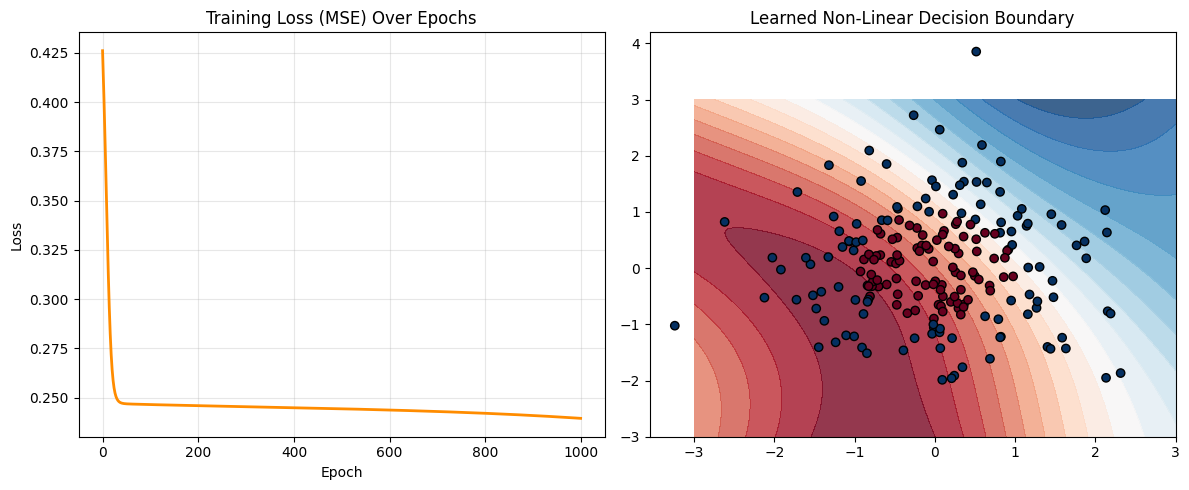

In [3]:
# Complete Pure NumPy 2-Layer Neural Network
class SimpleNeuralNet:
    def __init__(self, input_dim=2, hidden_dim=4, output_dim=1, lr=0.1):
        self.lr = lr
        # Initialize weights with small random numbers
        self.W1 = np.random.randn(input_dim, hidden_dim) * 0.5
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = np.random.randn(hidden_dim, output_dim) * 0.5
        self.b2 = np.zeros((1, output_dim))
        
    def sigmoid(self, z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -250, 250)))
    
    def sigmoid_deriv(self, a):
        return a * (1.0 - a)
    
    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2
    
    def backward(self, X, y, y_hat):
        m = X.shape[0]
        # Binary Cross-Entropy / MSE gradient
        dL_dz2 = (y_hat - y) * self.sigmoid_deriv(y_hat)
        dL_dW2 = np.dot(self.a1.T, dL_dz2) / m
        dL_db2 = np.sum(dL_dz2, axis=0, keepdims=True) / m
        
        dL_da1 = np.dot(dL_dz2, self.W2.T)
        dL_dz1 = dL_da1 * self.sigmoid_deriv(self.a1)
        dL_dW1 = np.dot(X.T, dL_dz1) / m
        dL_db1 = np.sum(dL_dz1, axis=0, keepdims=True) / m
        
        # Gradient Descent Step
        self.W2 -= self.lr * dL_dW2
        self.b2 -= self.lr * dL_db2
        self.W1 -= self.lr * dL_dW1
        self.b1 -= self.lr * dL_db1

# Generate synthetic non-linear dataset (XOR / Circle)
N = 200
X = np.random.randn(N, 2)
y = ((X[:, 0]**2 + X[:, 1]**2) < 1.0).astype(float).reshape(-1, 1)

# Train network
net = SimpleNeuralNet(input_dim=2, hidden_dim=8, output_dim=1, lr=0.5)
losses = []
for epoch in range(1000):
    y_pred = net.forward(X)
    loss = np.mean((y_pred - y)**2)
    losses.append(loss)
    net.backward(X, y, y_pred)

print(f"Final Loss after 1000 epochs: {losses[-1]:.4f}")

# Plot Loss curve and Decision Boundary
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(losses, color='darkorange', lw=2)
axes[0].set_title("Training Loss (MSE) Over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

# Decision Boundary Grid
xx, yy = np.meshgrid(np.linspace(-3, 3, 100), np.linspace(-3, 3, 100))
grid = np.c_[xx.ravel(), yy.ravel()]
probs = net.forward(grid).reshape(xx.shape)
axes[1].contourf(xx, yy, probs, levels=20, cmap='RdBu_r', alpha=0.8)
axes[1].scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap='RdBu_r', edgecolors='k')
axes[1].set_title("Learned Non-Linear Decision Boundary")
plt.tight_layout()
plt.show()


---

<br>

# ══════════════════════════════════════════════════════════════════════
# 🔥  Chapter 2: 02 · PyTorch Deep Dive
# ══════════════════════════════════════════════════════════════════════

> Tensors, autograd, nn.Module, DataLoaders, and the full training loop. This is the tool you will use for everything.

---

# 02. PyTorch Deep Dive: From Tensors to Training Loop

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/The-Pocket/PocketFlow-Tutorial-Video-Generator/blob/main/docs/llm/02_PyTorch_Deep_Dive.ipynb)

> **Tutorial Overview**: Build a complete, deep understanding of PyTorch. Tensors, Autograd, `nn.Module`, loss functions, optimizers, and constructing the industrial-strength training & evaluation loop.
> **Original Source**: `pytorch.md`

---


In [4]:
# Setup & Imports
!pip install -q torch torchvision matplotlib numpy

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch Version: {torch.__version__} on {device}")


zsh:1: command not found: pip
PyTorch Version: 2.8.0 on cpu


# **Give Me 1 Hour, You Will Build and Train a Neural Network From Scratch**

## Intro

You've seen PyTorch code. Maybe in a research paper or a tutorial. You saw `model.train()`, `loss.backward()`, and `optimizer.step()`.

You wondered what they actually *do*.

Maybe you tried to read the documentation. Got hit with a wall of classes. `nn.Module`, `torch.optim`, computation graphs. It felt like opaque, magical black boxes.

**Here's the truth: They're not black boxes. They are elegant wrappers for the linear algebra and calculus you already know.**

The entire deep learning training process, from the simplest model to a giant LLM, is just a five-step algorithm. That's it. Everything else is just an implementation detail.

- The `nn.Linear` layer? It's just `X @ W + b`.
- The loss function? Just a formula to measure error, like `torch.mean((y - y_hat)**2)`.
- The magical `loss.backward()`? It's just your old friend, the chain rule (backpropagation), automated.
- The `optimizer.step()`? It's just the gradient descent update rule: `W -= learning_rate * W.grad`.

**In this guide, we'll implement the raw math first, then use PyTorch's professional tools.**

You'll see *why* the tools exist by first doing the work manually. Once you've implemented the raw math, the professional code becomes obvious—just a clean, powerful way to organize what you've already built.

**And it all boils down to these 5 steps.**

Master this five-step loop, and you can understand the training code for any model, from a simple regression to a state-of-the-art Large Language Model.

| Step | Concept (Math) | From Scratch (Raw Tensors) | Professional (`torch.nn`) |
| :--- | :--- | :--- | :--- |
| **1. Prediction** | Make a prediction: <br> `ŷ = f(X, θ)` | `y_hat = X @ W + b` | `y_hat = model(X)` |
| **2. Loss Calc** | Quantify the error: <br> `L = Loss(ŷ, y)` | `loss = torch.mean((y_hat - y)**2)` | `loss = criterion(y_hat, y)` |
| **3. Gradient Calc** | Find the slope of the loss: <br> `∇_θ L` | `loss.backward()` | `loss.backward()` |
| **4. Param Update** | Step down the slope: <br> `θ_t+1 = θ_t - η * ∇_θ L` | `W -= lr * W.grad` | `optimizer.step()` |
| **5. Gradient Reset** | Reset for the next loop. | `W.grad.zero_()` | `optimizer.zero_grad()` |

Even better—this loop is universal. The `model` in Step 1 might become a massive Transformer, and the `optimizer` in Step 4 might be a fancy one like Adam, but the fundamental five-step logic **never changes**.

This isn't an analogy. The `nn.Linear` layer used in LLMs is the *exact same* `X @ W + b` operation you will build in Part 2. The Feed-Forward Network inside a Transformer is the *exact same* stack of layers you will build in Part 4. You are learning the literal, fundamental building blocks of modern AI.

Give me one hour. We'll build your understanding from the ground up. Raw math, real code, and a clear path to the professional tools.

Ready? Let's begin.

## Part 1: The Core Data Structure - `torch.Tensor`

Welcome to PyTorch! Everything we do—from loading data to defining complex neural networks—will be built on one core object: the `torch.Tensor`.

**The Analogy:** Think of a `Tensor` as the fundamental building block, the basic "noun" of the PyTorch language. It's a multi-dimensional array, very similar to a NumPy array, but with special powers for deep learning that we will unlock step-by-step.

Our goal in this section is to master this single, crucial object: how to create it and how to understand its properties.

### 1.1. The Three Common Patterns for Creating Tensors

There are many ways to create a tensor, but they generally fall into three common patterns you'll see everywhere.

#### **Pattern 1: Direct Creation from Existing Data**
This is the most straightforward. You have a Python list of numbers, and you want to convert it into a PyTorch tensor using `torch.tensor()`.


In [5]:
import torch

# Input: A standard Python list
data = [[1, 2, 3], [4, 5, 6]]
my_tensor = torch.tensor(data)

print(my_tensor)


tensor([[1, 2, 3],
        [4, 5, 6]])


**Output:**


In [6]:
tensor([[1, 2, 3],
        [4, 5, 6]])


NameError: name 'tensor' is not defined

---

#### **Pattern 2: Creation from a Desired Shape**
This is extremely common when building models. You don't know the exact values for your weights yet, but you know the dimensions (shape) you need.

*   `torch.ones()` or `torch.zeros()`: Fills the tensor with `1`s or `0`s.
*   `torch.randn()`: Fills the tensor with random numbers from a standard normal distribution. **This is the standard way to initialize a model's weights.**


In [ ]:
# Input: A shape tuple (2 rows, 3 columns)
shape = (2, 3)

# Create tensors with this shape
ones = torch.ones(shape)
zeros = torch.zeros(shape)
random = torch.randn(shape)

print(f"Ones Tensor:\n {ones}\n")
print(f"Zeros Tensor:\n {zeros}\n")
print(f"Random Tensor:\n {random}")


**Output:**


```python
Ones Tensor:
 tensor([[1., 1., 1.],
        [1., 1., 1.]])

Zeros Tensor:
 tensor([[0., 0., 0.],
        [0., 0., 0.]])

Random Tensor:
 tensor([[ 0.3815, -0.9388,  1.6793],
        [-0.3421,  0.5898,  0.3609]])
```


---

#### **Pattern 3: Creation by Mimicking Another Tensor's Properties**
Often, you have an existing tensor and you need to create a new one that has the *exact same shape, data type, and is on the same device*. Instead of manually copying these properties, PyTorch provides handy `_like` functions.


In [ ]:
# Input: A 'template' tensor
template = torch.tensor([[1, 2], [3, 4]])

# Create new tensors with the same properties as the template
ones_like = torch.ones_like(template)
rand_like = torch.randn_like(template, dtype=torch.float) # dtype can be overridden

print(f"Template Tensor:\n {template}\n")
print(f"Ones_like Tensor:\n {ones_like}\n")
print(f"Randn_like Tensor:\n {rand_like}")


**Output:**


```python
Template Tensor:
 tensor([[1, 2],
        [3, 4]])

Ones_like Tensor:
 tensor([[1, 1],
        [1, 1]])

Randn_like Tensor:
 tensor([[-1.1713, -0.2032],
        [ 0.3391, -0.8267]])
```


### 1.2. What's Inside a Tensor? Shape, Type, and Device

Every tensor has attributes that describe its metadata. The three you will use constantly are `.shape`, `.dtype`, and `.device`.


In [ ]:
# Let's create a tensor to inspect
tensor = torch.randn(2, 3)

print(f"Shape of tensor: {tensor.shape}")
print(f"Datatype of tensor: {tensor.dtype}")
print(f"Device tensor is stored on: {tensor.device}")


**Output:**


```python
Shape of tensor: torch.Size([2, 3])
Datatype of tensor: torch.float32
Device tensor is stored on: cpu
```


Let's break these down:
*   **`.shape`**: This is a tuple that describes the dimensions of the tensor. `torch.Size([2, 3])` tells us it's a 2D tensor with 2 rows and 3 columns. This is the most important attribute for debugging your models. Mismatched shapes are the #1 source of errors in PyTorch.
*   **`.device`**: This tells you where the tensor's data is physically stored. By default, it's on the `cpu`. If you have a compatible GPU, you can move it there (`.to("cuda")`) for massive speedups.
*   **`.dtype`**: This describes the data type of the numbers inside the tensor. Notice it defaulted to `torch.float32`. This is not an accident, and it's critically important.

#### A Quick but Critical Note on `dtype`
Why `torch.float32` and not just regular integers (`int64`)? The answer is **gradients**.

Gradient descent, the engine of deep learning, works by making tiny, continuous adjustments to a model's weights. These adjustments are fractional numbers (like `-0.0012`), which require a floating-point data type. You can't nudge a parameter from `3` to `3.001` if your data type only allows whole numbers.

**Key Takeaway:**
*   Model parameters (weights and biases) **must** be a float type (`float32` is the standard).
*   Data that represents categories or counts (like word IDs) can be integers (`int64`).

---

We now know what a `torch.Tensor` is and how to create one using three common patterns. We've essentially learned about the raw material.

Now, let's explore the single most important switch that turns this simple data container into a core component of a dynamic learning machine. Let's move on to **Part 2: The Engine of Autograd**.

## Part 2: The Engine of Autograd - `requires_grad`

In Part 1, we learned that tensors are containers for numbers. But their real power comes from a system called **Autograd**, which stands for automatic differentiation. This is PyTorch's built-in gradient calculator.

**The Analogy:** If a tensor is the "noun" in PyTorch, then Autograd is the "nervous system." It connects all the operations and allows signals (gradients) to flow backward through the system, enabling learning.

Our goal here is to understand the *one simple switch* that activates this nervous system.

### 2.1. The "Magic Switch": `requires_grad=True`

By default, PyTorch assumes a tensor is just static data. To tell it that a tensor is a learnable parameter (like a model's weight or bias), you must set its `requires_grad` attribute to `True`.

This is the most important setting in all of PyTorch. It tells Autograd:
> "This is a parameter my model will learn. From now on, track every single operation that happens to it."


In [ ]:
# A standard data tensor (we don't need to calculate gradients for our input data)
x_data = torch.tensor([[1., 2.], [3., 4.]])
print(f"Data tensor requires_grad: {x_data.requires_grad}\n")

# A parameter tensor (we need to learn this, so we need gradients)
w = torch.tensor([[1.0], [2.0]], requires_grad=True)
print(f"Parameter tensor requires_grad: {w.requires_grad}")


**Output:**


```python
Data tensor requires_grad: False

Parameter tensor requires_grad: True
```


### 2.2. The Computation Graph: How PyTorch Remembers

Once you set `requires_grad=True`, PyTorch starts building a **computation graph** behind the scenes. Think of it as a history of all the operations. Every time you perform an operation on a tensor that requires gradients, PyTorch adds a new node to this graph.

Let's build a simple one. We'll compute `z = x * y` where `y = a + b`.


In [ ]:
# Three parameter tensors that we want to learn
a = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(3.0, requires_grad=True)
x = torch.tensor(4.0, requires_grad=True)

# First operation: y = a + b
y = a + b

# Second operation: z = x * y
z = x * y

print(f"Result of a + b: {y}")
print(f"Result of x * y: {z}")


**Output:**


```python
Result of a + b: 5.0
Result of x * y: 20.0
```


The math is simple. But behind the scenes, PyTorch has built a graph connecting `a`, `b`, `x`, `y`, and `z`.

### 2.3. Peeking Under the Hood: The `.grad_fn` Attribute

How can we prove this graph exists? Every tensor that is the result of an operation on a `requires_grad` tensor will have a special attribute called `.grad_fn`. This attribute is a "breadcrumb" that points to the function that created it.

Let's inspect the tensors from our previous example.


In [ ]:
# z was created by multiplication
print(f"grad_fn for z: {z.grad_fn}")

# y was created by addition
print(f"grad_fn for y: {y.grad_fn}")

# a was created by the user, not by an operation, so it has no grad_fn
print(f"grad_fn for a: {a.grad_fn}")


**Output:**


```python
grad_fn for z: <MulBackward0 object at 0x10f7d3d90>
grad_fn for y: <AddBackward0 object at 0x10f7d3d90>
grad_fn for a: None
```


This is the tangible proof of the computation graph. PyTorch knows `z` came from a multiplication (`MulBackward0`) and `y` came from an addition (`AddBackward0`). When we later ask it to compute gradients, it will use this information to trace its way backward through the graph using the chain rule.

### 2.4. Visualizing the Graph

Here is what the graph we just created looks like. The `grad_fn` is the "arrow" leading to each new tensor.


```mermaid
graph TD
    A[Tensor a=2.0] --> C{Add};
    B[Tensor b=3.0] --> C{Add};
    C -- y = a + b --> D[Tensor y=5.0<br>grad_fn=&lt;AddBackward0&gt;];
    D --> E{Multiply};
    F[Tensor x=4.0] --> E{Multiply};
    E -- z = x * y --> G[Tensor z=20.0<br>grad_fn=&lt;MulBackward0&gt;];
```


---

We have now learned how to activate PyTorch's "nervous system" by setting `requires_grad=True`. This allows PyTorch to build a computation graph and remember the history of all operations.

We have built the network of roads. In the next parts, we'll learn the common operations (the "verbs") and then see how to send the gradient signal flowing backward along these roads to enable learning. Let's move on to **Part 3: Basic Mathematical & Reduction Operations**.

## Part 3: Basic Mathematical & Reduction Operations

We have our `Tensor` (the noun) and `Autograd` (the nervous system). Now we need **operations** (the verbs) to describe the calculations our model will perform. In deep learning, the vast majority of these operations are surprisingly simple: matrix multiplications and aggregations.

Our goal is to master these core verbs and, most importantly, the critical `dim` argument that controls how they work.

### 3.1. Mathematical Operations: `*` vs. `@`

This is the single most common point of confusion for beginners. PyTorch has two very different kinds of multiplication.

**1. Element-wise Multiplication (`*`)**
This operation multiplies elements in the same position. It's like overlaying two tensors and multiplying the corresponding cells. The tensors **must have the same shape**.


In [ ]:
a = torch.tensor([[1, 2], [3, 4]])
b = torch.tensor([[10, 20], [30, 40]])

# Calculation: [[1*10, 2*20], [3*30, 4*40]]
element_wise_product = a * b

print(f"Tensor a:\n {a}\n")
print(f"Tensor b:\n {b}\n")
print(f"Element-wise Product (a * b):\n {element_wise_product}")


**Output:**


```python
Tensor a:
 tensor([[1, 2],
        [3, 4]])

Tensor b:
 tensor([[10, 20],
        [30, 40]])

Element-wise Product (a * b):
 tensor([[ 10,  40],
        [ 90, 160]])
```


---

**2. Matrix Multiplication (`@`)**
This is the standard matrix product from linear algebra. It's the core operation of every `Linear` layer in a neural network. For `m1 @ m2`, the number of columns in `m1` must equal the number of rows in `m2`.


In [ ]:
m1 = torch.tensor([[1, 2, 3], [4, 5, 6]])   # Shape: (2, 3)
m2 = torch.tensor([[7, 8], [9, 10], [11, 12]]) # Shape: (3, 2)

# Calculation for the first element: (1*7) + (2*9) + (3*11) = 58
matrix_product = m1 @ m2 # Resulting shape: (2, 2)

print(f"Matrix 1 (shape {m1.shape}):\n {m1}\n")
print(f"Matrix 2 (shape {m2.shape}):\n {m2}\n")
print(f"Matrix Product (m1 @ m2):\n {matrix_product}")


**Output:**


```python
Matrix 1 (shape torch.Size([2, 3])):
 tensor([[1, 2, 3],
        [4, 5, 6]])

Matrix 2 (shape torch.Size([3, 2])):
 tensor([[ 7,  8],
        [ 9, 10],
        [11, 12]])

Matrix Product (m1 @ m2):
 tensor([[ 58,  64],
        [139, 154]])
```


### 3.2. Reduction Operations

A "reduction" is any operation that reduces the number of elements in a tensor, often by aggregating them. Examples include `sum()`, `mean()`, `max()`, and `min()`.


In [ ]:
scores = torch.tensor([[10., 20., 30.], [5., 10., 15.]])

# By default, reductions apply to the entire tensor
total_sum = scores.sum()
average_score = scores.mean()

print(f"Scores Tensor:\n {scores}\n")
# Calculation: 10 + 20 + 30 + 5 + 10 + 15 = 90
print(f"Total Sum: {total_sum}")
# Calculation: 90 / 6 = 15
print(f"Overall Mean: {average_score}")


**Output:**


```python
Scores Tensor:
 tensor([[10., 20., 30.],
        [ 5., 10., 15.]])

Total Sum: 90.0
Overall Mean: 15.0
```


### 3.3. The `dim` Argument: The Most Important Detail

This is where reductions become powerful. The `dim` argument tells the function which dimension to **collapse**.

A simple rule of thumb for 2D tensors:
*   `dim=0`: Collapses the **rows** (operates "vertically" ⬇️).
*   `dim=1`: Collapses the **columns** (operates "horizontally" ➡️).

Let's use our `scores` tensor (2 students, 3 assignments) to see this.


In [ ]:
scores = torch.tensor([[10., 20., 30.], [5., 10., 15.]])

# To get the sum FOR EACH ASSIGNMENT, we collapse the student dimension (dim=0)
# Calculation: [10+5, 20+10, 30+15]
sum_per_assignment = scores.sum(dim=0)

# To get the sum FOR EACH STUDENT, we collapse the assignment dimension (dim=1)
# Calculation: [10+20+30, 5+10+15]
sum_per_student = scores.sum(dim=1)

print(f"Original Scores:\n {scores}\n")
print(f"Sum per assignment (dim=0): {sum_per_assignment}")
print(f"Sum per student (dim=1):    {sum_per_student}")


**Output:**


```python
Original Scores:
 tensor([[10., 20., 30.],
        [ 5., 10., 15.]])

Sum per assignment (dim=0): tensor([15., 30., 45.])
Sum per student (dim=1):    tensor([60., 30.])
```


This table visualizes exactly what happened:

| `scores` | Assignment 1 | Assignment 2 | Assignment 3 | `sum(dim=1)` ➡️ |
| :--- | :---: | :---: | :---: | :---: |
| Student 1 | 10 | 20 | 30 | **60** |
| Student 2 | 5 | 10 | 15 | **30** |
| `sum(dim=0)` ⬇️ | **15** | **30** | **45** | |

Mastering the `dim` argument is essential for everything from calculating loss functions to implementing attention mechanisms.

---

We now have the basic vocabulary of calculation and aggregation. We know how to multiply matrices and how to sum up results across specific dimensions.

Now let's look at more advanced "verbs" for selecting and manipulating data. Let's move on to **Part 4: Advanced Indexing & Selection Primitives**.

## Part 4: Advanced Indexing & Selection Primitives

If basic math ops are the "verbs" of PyTorch, then indexing primitives are the "adverbs" and "prepositions"—they let you specify *which* data to act upon with great precision.

Our goal is to learn how to select data in increasingly sophisticated ways, moving from uniform block selection to dynamic, per-row lookups.

### 4.1. Standard Indexing: The Basics

This works just like in Python lists or NumPy. It's for selecting uniform "blocks" of data, like entire rows or columns.


In [ ]:
# A simple, easy-to-read tensor
x = torch.tensor([[0, 1, 2, 3],
                  [4, 5, 6, 7],
                  [8, 9, 10, 11]])

# Get the second row (at index 1)
row_1 = x[1]
print(f"Row 1: {row_1}\n")

# Get the third column (at index 2)
col_2 = x[:, 2]
print(f"Column 2: {col_2}\n")

# Get a specific element (row 1, column 3)
element_1_3 = x[1, 3]
print(f"Element at (1, 3): {element_1_3}")


**Output:**


```python
Row 1: tensor([4, 5, 6, 7])

Column 2: tensor([ 2,  6, 10])

Element at (1, 3): 7
```


### 4.2. Boolean Masking: Selection by Condition

Instead of using integer indices, you can use a boolean (True/False) tensor to select only the elements where the mask is `True`.


In [ ]:
x = torch.tensor([[0, 1, 2, 3], [4, 5, 6, 7]])

# Step 1: Create the boolean mask
mask = x > 3
print(f"The Boolean Mask (x > 3):\n {mask}\n")

# Step 2: Apply the mask to the tensor
selected_elements = x[mask]
print(f"Selected elements: {selected_elements}")


**Output:**


```python
The Boolean Mask (x > 3):
 tensor([[False, False, False, False],
        [ True,  True,  True,  True]])

Selected elements: tensor([4, 5, 6, 7])
```


**Note:** Boolean selection always returns a 1D tensor, as it pulls out only the matching values.

### 4.3. Conditional Creation: `torch.where()`

This is the tensor equivalent of a ternary `if/else` statement. It creates a **new tensor** by choosing values from two other tensors based on a condition. The syntax is `torch.where(condition, value_if_true, value_if_false)`.


In [ ]:
x = torch.tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

# Create a new tensor: if a value in x is > 4, use -1, otherwise use the original value
y = torch.where(x > 4, -1, x)

print(f"Original Tensor: {x}")
print(f"Result of where: {y}")


**Output:**


```python
Original Tensor: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
Result of where: tensor([ 0,  1,  2,  3,  4, -1, -1, -1, -1, -1])
```


### 4.4. Primitives for Finding the "Best" Items

After a model makes a prediction, we often need to find the item with the highest score.
*   `torch.argmax()`: Finds the **index** of the single maximum value.
*   `torch.topk()`: Finds the `k` largest **values and their indices**.


In [ ]:
scores = torch.tensor([
    [10, 0, 5, 20, 1],  # Scores for item 0
    [1, 30, 2, 5, 0]   # Scores for item 1
])

# Find the index of the best score for each item
best_indices = torch.argmax(scores, dim=1)
# For row 0, max is 20 at index 3. For row 1, max is 30 at index 1.
print(f"Argmax indices: {best_indices}\n")

# Find the top 3 scores and their indices for each item
top_values, top_indices = torch.topk(scores, k=3, dim=1)
print(f"Top 3 values:\n {top_values}\n")
print(f"Top 3 indices:\n {top_indices}")


**Output:**


```python
Argmax indices: tensor([3, 1])

Top 3 values:
 tensor([[20, 10,  5],
        [30,  5,  2]])

Top 3 indices:
 tensor([[3, 0, 2],
        [1, 3, 2]])
```


### 4.5. Primitive for Dynamic Lookups: `torch.gather()`

This is the most advanced and powerful selection tool.

**The Problem:** Standard indexing is for *uniform* selection (e.g., "get column 2 for *all* rows"). But what if you need to select a **different column for each row**?
*   From row 0, get the element at column 2.
*   From row 1, get the element at column 0.
*   From row 2, get the element at column 3.

**The Solution:** `torch.gather()` is purpose-built for this "dynamic lookup." You provide an `index` tensor that acts as a personalized list of which element to grab from each row.


In [ ]:
data = torch.tensor([
    [10, 11, 12, 13],  # row 0
    [20, 21, 22, 23],  # row 1
    [30, 31, 32, 33]   # row 2
])

# Our "personalized list" of column indices to select from each row
indices_to_select = torch.tensor([[2], [0], [3]])

# Gather from `data` along dim=1 (the column dimension)
selected_values = torch.gather(data, dim=1, index=indices_to_select)

print(f"Selected Values:\n {selected_values}")


**Output:**


```python
Selected Values:
 tensor([[12],  # From row 0, we gathered the element at index 2
        [20],  # From row 1, we gathered the element at index 0
        [33]]) # From row 2, we gathered the element at index 3
```


This single, optimized operation avoids a slow Python `for` loop and is a cornerstone of many advanced model architectures.

---

We have now learned a powerful set of verbs for calculation, aggregation, and selection. We have all the tools we need.

It's time to put them together. Let's start building our neural network from scratch. Let's move on to **Part 5: The Forward Pass - Manually Making a Prediction**.

## Part 5: The Forward Pass - Manually Making a Prediction

The **"Forward Pass"** is the process of taking input data and passing it *forward* through the model's layers to get an output, or prediction. It's the first step in our five-step training loop.

**The Analogy:** Think of the forward pass as the model's "guess." We show it a problem (the input `X`) and it gives us its current best answer (the prediction `ŷ`).

Our goal is to implement a simple linear regression model's forward pass from scratch, using only the raw tensor operations we've already learned.

### 5.1. The Model: Simple Linear Regression

Our model's job is to learn the relationship between one input variable (`x`) and one output variable (`y`). The formula from linear algebra is our blueprint:

`ŷ = XW + b`

Where:
*   `X` is our input data.
*   `W` is the **weight** parameter.
*   `b` is the **bias** parameter.
*   `ŷ` (pronounced "y-hat") is our model's **prediction**.

Our goal is to find the best `W` and `b` to make `ŷ` as close to the true `y` as possible.

### 5.2. The Setup: Creating Our Data

We don't have a real dataset, so let's create a synthetic one. We'll generate data that follows a clear pattern, and then see if our model can learn it. Let's create data that follows the line `y = 2x + 1`, with a little bit of random noise added.


In [ ]:
# We'll create a "batch" of 10 data points
N = 10
# Each data point has 1 feature
D_in = 1
# The output for each data point is a single value
D_out = 1

# Create our input data X
# Shape: (10 rows, 1 column)
X = torch.randn(N, D_in)

# Create our true target labels y by applying the "true" function
# and adding some noise for realism
true_W = torch.tensor([[2.0]])
true_b = torch.tensor(1.0)
y_true = X @ true_W + true_b + torch.randn(N, D_out) * 0.1 # Add a little noise

print(f"Input Data X (first 3 rows):\n {X[:3]}\n")
print(f"True Labels y_true (first 3 rows):\n {y_true[:3]}")


**Output:**


```python
Input Data X (first 3 rows):
 tensor([[-0.5186],
        [-0.2582],
        [-0.3378]])

True Labels y_true (first 3 rows):
 tensor([[-0.1030],
        [ 0.4491],
        [ 0.3340]])
```


### 5.3. The Parameters: The Model's "Brain"

Now, we create the parameters `W` and `b` that our model will learn. We initialize them with random values. Most importantly, we set `requires_grad=True` to tell PyTorch's Autograd engine to start tracking them.


In [ ]:
# Initialize our parameters with random values
# Shapes must be correct for matrix multiplication: X(10,1) @ W(1,1) -> (10,1)
W = torch.randn(D_in, D_out, requires_grad=True)
b = torch.randn(1, requires_grad=True)

print(f"Initial Weight W:\n {W}\n")
print(f"Initial Bias b:\n {b}")


**Output:**


```python
Initial Weight W:
 tensor([[0.4137]], requires_grad=True)

Initial Bias b:
 tensor([0.2882], requires_grad=True)
```


Our model's current "knowledge" is that the weight is `0.4137` and the bias is `0.2882`. This is completely random and wrong, but it's a starting point.

### 5.4. The Implementation: From Math to Code

Now for the main event. We translate our mathematical formula `ŷ = XW + b` directly into a single line of PyTorch code.


In [ ]:
# Perform the forward pass to get our first prediction
y_hat = X @ W + b

print(f"Shape of our prediction y_hat: {y_hat.shape}\n")
print(f"Prediction y_hat (first 3 rows):\n {y_hat[:3]}\n")
print(f"True Labels y_true (first 3 rows):\n {y_true[:3]}")


**Output:**


```python
Shape of our prediction y_hat: torch.Size([10, 1])

Prediction y_hat (first 3 rows):
 tensor([[ 0.0737],
        [ 0.1812],
        [ 0.1485]], grad_fn=<AddBackward0>)

True Labels y_true (first 3 rows):
 tensor([[-0.1030],
        [ 0.4491],
        [ 0.3340]])
```


Notice two things:
1.  The shape of `y_hat` is `(10, 1)`, which perfectly matches the shape of `y_true`. This is crucial.
2.  `y_hat` has a `grad_fn=<AddBackward0>`. This is Autograd at work! PyTorch has already built the computation graph, remembering that `y_hat` was created by adding the bias `b` to the result of the matrix multiplication `X @ W`.

As expected, our initial predictions are terrible. They're nowhere near the true labels. This is because our `W` and `b` are random.

We've successfully made a guess. The next logical question is: **how do we measure exactly *how wrong* our guess is?**

This leads us directly to the concept of the loss function. Let's move on to **Part 6: The Backward Pass - Manually Calculating Gradients**.

## Part 6: The Backward Pass - Calculating Gradients

If the forward pass was the model's "guess," the backward pass is the "post-mortem analysis." We compare the guess to the truth, calculate how wrong we were, and then determine *exactly how to change each parameter* to be less wrong next time.

**The Analogy:** Imagine you're tuning a complex radio with two knobs (`W` and `b`) to get a clear signal (the true `y`). The forward pass is listening to the current static (`y_hat`). The backward pass is figuring out which direction to turn each knob (`W.grad` and `b.grad`) to reduce the static.

Our goal is to quantify our model's error and then use Autograd's magic to calculate the gradients—the direction of steepest ascent of the error.

### 6.1. Defining Error: The Loss Function

We need a single number that tells us how "wrong" our predictions are. This is called the **Loss**. For regression, the most common loss function is the **Mean Squared Error (MSE)**.

The formula is simple:
`L = (1/N) * Σ(ŷ_i - y_i)²`

In plain English: "For every data point, find the difference between the prediction and the truth, square it, and then take the average of all these squared differences."

Let's translate this directly into PyTorch code, using the `y_hat` from Part 5.


In [ ]:
# y_hat is our prediction from the forward pass
# y_true is the ground truth
# Let's calculate the loss manually
error = y_hat - y_true
squared_error = error ** 2
loss = squared_error.mean()

print(f"Prediction (first 3):\n {y_hat[:3]}\n")
print(f"Truth (first 3):\n {y_true[:3]}\n")
print(f"Loss (a single number): {loss}")


**Output:**


```python
Prediction (first 3):
 tensor([[ 0.0737],
        [ 0.1812],
        [ 0.1485]], grad_fn=<SliceBackward0>)

Truth (first 3):
 tensor([[-0.1030],
        [ 0.4491],
        [ 0.3340]])

Loss (a single number): 1.6322047710418701
```


We now have a single number, `1.6322`, that quantifies our model's total error. Our goal is to make this number as small as possible. Notice that the `loss` tensor also has a `grad_fn`, because it's the result of operations on our parameters. It's the root of our computation graph.

### 6.2. The Magic Command: `loss.backward()`

This is where the magic of Autograd happens. With a single command, we tell PyTorch to send a signal backward from the `loss` through the entire computation graph it built during the forward pass.

This command calculates the gradient of the `loss` with respect to every single parameter that has `requires_grad=True`. In our case, it will compute:
*   `∂L/∂W` (the gradient of the Loss with respect to our Weight `W`)
*   `∂L/∂b` (the gradient of the Loss with respect to our Bias `b`)


In [ ]:
# The backward pass
loss.backward()


**Output:**
*(There is no direct output, but something very important has happened in the background.)*

PyTorch has now populated the `.grad` attribute for our `W` and `b` tensors.

### 6.3. Inspecting the Result: The `.grad` Attribute

The `.grad` attribute now holds the gradient for each parameter. This is the "signal" that tells us how to adjust our knobs.


In [ ]:
# The gradients are now stored in the .grad attribute of our parameters
print(f"Gradient for W (∂L/∂W):\n {W.grad}\n")
print(f"Gradient for b (∂L/∂b):\n {b.grad}")


**Output:**


```python
Gradient for W (∂L/∂W):
 tensor([[-1.0185]])

Gradient for b (∂L/∂b):
 tensor([-2.0673])
```


#### **How to Interpret These Gradients:**

*   **`W.grad` is -1.0185:** The negative sign is key. It means that if we were to *increase* `W`, the loss would *decrease*. The gradient points in the direction of the steepest *increase* in loss, so we'll want to move in the opposite direction.
*   **`b.grad` is -2.0673:** Similarly, this tells us that increasing `b` will also decrease the loss.

We now have everything we need to improve our model:
1.  A way to measure error (the loss).
2.  The exact direction to turn our parameter "knobs" to reduce that error (the gradients).

We have completed the analysis. The final step is to actually *act* on this information—to update our weights and biases.

This leads us to the heart of the training process. Let's move on to **Part 7: The Training Loop - Gradient Descent in Action**.

## Part 7: The Training Loop - Gradient Descent From Scratch

This is the heart of the entire deep learning process. The **Training Loop** repeatedly executes the forward and backward passes, incrementally updating the model's parameters to minimize the loss. This process is called **Gradient Descent**.

**The Analogy:** We're standing on a foggy mountain (the loss landscape) and want to get to the lowest valley (minimum loss). We can't see the whole map, but we can feel the slope of the ground beneath our feet (the gradients). The training loop is the process of taking a small step downhill, feeling the slope again, taking another step, and repeating until we reach the bottom.

Our goal is to implement this "step-by-step" descent from scratch.

### 7.1. The Algorithm: Gradient Descent

The core update rule for gradient descent was promised in the very beginning, and now we can finally implement it:

`θ_t+1 = θ_t - η * ∇_θ L`

Let's translate this from math to our context:
*   `θ`: Represents all our parameters, `W` and `b`.
*   `η` (eta): The **learning rate**, a small number that controls how big of a step we take.
*   `∇_θ L`: The gradient of the loss with respect to our parameters, which we now have in `W.grad` and `b.grad`.

So, the update rules for our model are:
1.  `W_new = W_old - learning_rate * W.grad`
2.  `b_new = b_old - learning_rate * b.grad`

### 7.2. The Loop: Putting It All Together

Let's write a `for` loop that performs these steps for a set number of `epochs` (one epoch is one full pass through our training data).

We will add two new, critical details inside the loop:
1.  **`with torch.no_grad():`**: The weight update step should *not* be part of the computation graph. It's an external intervention by the "optimizer" (us, in this case). We wrap it in this block to tell PyTorch, "Don't track this operation for gradient purposes."
2.  **`.grad.zero_()`**: After we update our weights, we must manually reset the gradients to zero. If we don't, the gradients from the next backward pass will be *added* to the old ones, which is incorrect.


In [ ]:
# Hyperparameters
learning_rate = 0.01
epochs = 100

# Let's re-initialize our random parameters
W = torch.randn(1, 1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

print(f"Starting Parameters: W={W.item():.3f}, b={b.item():.3f}\n")

# The Training Loop
for epoch in range(epochs):
    ### STEP 1 & 2: Forward Pass and Loss Calculation ###
    y_hat = X @ W + b
    loss = torch.mean((y_hat - y_true)**2)

    ### STEP 3: Backward Pass (Calculate Gradients) ###
    loss.backward()

    ### STEP 4: Update Parameters (The Gradient Descent Step) ###
    # We wrap this in no_grad() because this is not part of the model's computation
    with torch.no_grad():
        W -= learning_rate * W.grad
        b -= learning_rate * b.grad

    ### STEP 5: Zero the Gradients ###
    # We must reset the gradients for the next iteration
    W.grad.zero_()
    b.grad.zero_()

    # Optional: Print progress
    if epoch % 10 == 0:
        print(f"Epoch {epoch:02d}: Loss={loss.item():.4f}, W={W.item():.3f}, b={b.item():.3f}")

print(f"\nFinal Parameters: W={W.item():.3f}, b={b.item():.3f}")
print(f"True Parameters:  W=2.000, b=1.000")


### 7.3. Watching the Model Learn

Let's look at the output. We can literally see the learning happen.

**Output:**


```python
Starting Parameters: W=-0.369, b=0.485

Epoch 00: Loss=4.1451, W=-0.347, b=0.505
Epoch 10: Loss=1.0454, W=0.485, b=0.887
Epoch 20: Loss=0.2917, W=0.970, b=1.077
Epoch 30: Loss=0.1068, W=1.251, b=1.155
Epoch 40: Loss=0.0592, W=1.422, b=1.178
Epoch 50: Loss=0.0441, W=1.528, b=1.178
Epoch 60: Loss=0.0381, W=1.600, b=1.168
Epoch 70: Loss=0.0354, W=1.650, b=1.154
Epoch 80: Loss=0.0339, W=1.685, b=1.140
Epoch 90: Loss=0.0329, W=1.711, b=1.127

Final Parameters: W=1.731, b=1.115
True Parameters:  W=2.000, b=1.000
```


This table is the most beautiful thing in deep learning. We can see:
1.  The **Loss** is steadily decreasing, from a high of `4.1451` down to `0.0329`. The model is getting less wrong.
2.  The **Weight `W`** is moving from its random start (`-0.369`) towards the true value of `2.0`.
3.  The **Bias `b`** is moving from its random start (`0.485`) towards the true value of `1.0`.

It works! We have successfully implemented the entire gradient descent algorithm from scratch using raw PyTorch tensors and Autograd. We have built a machine that learns.

---

This "from scratch" approach gave us deep insight into the mechanics. However, it's also verbose and error-prone. What if we had 50 layers? Manually updating each parameter and zeroing its gradient would be a nightmare.

This is why PyTorch provides professional abstractions. Let's start exploring them by looking at pre-built layers. Let's move on to **Part 8: Professional Building Blocks - `torch.nn` Layers**.

## Part 8: Professional Building Blocks - `torch.nn` Layers

Manually creating and managing weights (`W`) and biases (`b`) is great for understanding the fundamentals, but it doesn't scale. As models get more complex, we need a better way to organize our parameters.

This is where the `torch.nn` module comes in. It's a library of pre-built layers and tools that form the backbone of virtually all PyTorch models.

**The Analogy:** If raw tensors are like clay, `torch.nn` layers are like pre-made, standardized LEGO bricks. You can still build anything you want, but the process is faster, more robust, and easier to understand.

Our goal is to learn about the most essential "bricks" in this toolkit, especially those relevant for building LLMs.

### 8.1. The Workhorse: `torch.nn.Linear`

The `torch.nn.Linear` layer does exactly what our manual `X @ W + b` operation did. It's a container that holds the `W` and `b` tensors for a linear transformation and performs the operation for us.

Let's see how it replaces our manual setup.


In [ ]:
# The input to our model has 1 feature (D_in=1)
# The output of our model is 1 value (D_out=1)
D_in = 1
D_out = 1

# Create a Linear layer
linear_layer = torch.nn.Linear(in_features=D_in, out_features=D_out)

# You can inspect the randomly initialized parameters inside
print(f"Layer's Weight (W): {linear_layer.weight}\n")
print(f"Layer's Bias (b): {linear_layer.bias}\n")

# You use it just like a function. Let's pass our data X through it.
# This performs the forward pass: X @ W.T + b
# (Note: nn.Linear stores W as (D_out, D_in), so it uses a transpose)
y_hat_nn = linear_layer(X)

print(f"Output of nn.Linear (first 3 rows):\n {y_hat_nn[:3]}")


**Output:**


```python
Layer's Weight (W): Parameter containing:
tensor([[-0.9238]], requires_grad=True)

Layer's Bias (b): Parameter containing:
tensor([0.7699], requires_grad=True)

Output of nn.Linear (first 3 rows):
 tensor([[1.2494],
        [1.0089],
        [1.0827]], grad_fn=<SliceBackward0>)
```


Notice that `linear_layer.weight` and `linear_layer.bias` are of type `Parameter`. This is a special kind of tensor that automatically has `requires_grad=True` and tells PyTorch, "This is a parameter that belongs to an `nn.Module`."

### 8.2. Introducing Non-Linearity: Activation Functions

Linear models are powerful, but they are fundamentally limited: stacking multiple linear layers on top of each other is mathematically the same as just having one larger linear layer. They can only learn linear relationships.

To learn complex, real-world patterns, neural networks need to introduce "kinks" or non-linearities between these linear layers. This is the job of an **activation function**.

Let's explore the three most important ones.

---

#### **`nn.ReLU` (Rectified Linear Unit)**

This is the most common activation function for general-purpose neural networks. Its rule is incredibly simple: if the input `x` is negative, the output is `0`. If the input `x` is positive, the output is `x`.

*   **Formula:** `ReLU(x) = max(0, x)`
*   **Behavior:** It "turns off" neurons that have a negative activation.
*   **Learnable Parameters:** No. It's a fixed mathematical function.


In [ ]:
# Create a ReLU activation function layer
relu = torch.nn.ReLU()

# Let's create some sample data with positive and negative values
sample_data = torch.tensor([-2.0, -0.5, 0.0, 0.5, 2.0])

# Apply the activation
activated_data = relu(sample_data)

print(f"Original Data:      {sample_data}")
print(f"Data after ReLU:    {activated_data}")


**Output:**


```python
Original Data:      tensor([-2.0000, -0.5000,  0.0000,  0.5000,  2.0000])
Data after ReLU:    tensor([0.0000, 0.0000, 0.0000, 0.5000, 2.0000])
```


As you can see, all negative inputs were clamped to zero, while positive inputs remained unchanged.

---

#### **`nn.GELU` (Gaussian Error Linear Unit)**

This is the modern standard for high-performance models, especially Transformers like BERT and GPT. It's a smoother, "probabilistic" version of ReLU. Instead of a hard "off" switch at zero, it smoothly de-weights inputs based on their magnitude.

*   **Formula:** The exact formula is `GELU(x) = x * Φ(x)`, where `Φ(x)` is the Cumulative Distribution Function (CDF) of the standard normal distribution. A common approximation is:
    $$ \text{GELU}(x) \approx 0.5x \left(1 + \tanh\left[\sqrt{\frac{2}{\pi}}\left(x + 0.044715x^3\right)\right]\right) $$
*   **Behavior:** It acts like ReLU for large positive values, but it smoothly curves to zero for negative values, allowing some gradient to flow through even for negative inputs.
*   **Learnable Parameters:** No. It's a fixed mathematical function.


In [ ]:
# Create a GELU activation function layer
gelu = torch.nn.GELU()

# Use the same sample data
sample_data = torch.tensor([-2.0, -0.5, 0.0, 0.5, 2.0])

# Apply the activation
activated_data = gelu(sample_data)

print(f"Original Data:      {sample_data}")
print(f"Data after GELU:    {activated_data}")


**Output:**


```python
Original Data:      tensor([-2.0000, -0.5000,  0.0000,  0.5000,  2.0000])
Data after GELU:    tensor([-0.0455, -0.1545,  0.0000,  0.3455,  1.9545])
```


Notice the difference from ReLU: the negative inputs are not zero but are "squashed" towards zero. This smoother behavior has been shown to lead to better performance in state-of-the-art models.

---

#### **`nn.Softmax`**

Softmax is a special activation function used almost exclusively on the **final output layer of a classification model**. Its job is to take a vector of raw, unbounded scores (called **logits**) and convert them into a probability distribution.

*   **Formula:** For a vector of logits `z = [z_1, z_2, ..., z_K]`, the Softmax of the i-th element is:
    $$ \text{Softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}} $$
*   **Behavior:** It exponentiates every logit (making them all positive) and then normalizes them by dividing by the sum of all exponentiated logits. The result is a vector where:
    1.  Every element is between 0 and 1.
    2.  All elements sum to 1.
*   **Learnable Parameters:** It has **no learnable parameters**. It's a fixed normalization function. The model learns by adjusting the *logits* that are fed *into* the Softmax.


In [ ]:
# Softmax must be told which dimension contains the scores to be normalized.
# For a batch of predictions, this is typically the last dimension (dim=-1 or dim=1).
softmax = torch.nn.Softmax(dim=-1)

# Let's create some sample logits for a batch of 2 items, with 4 possible classes
# A higher number means the model is more confident in that class.
logits = torch.tensor([
    [1.0, 3.0, 0.5, 1.5],  # Logits for item 1
    [-1.0, 2.0, 1.0, 0.0]   # Logits for item 2
])

# Apply the softmax
probabilities = softmax(logits)

print(f"Original Logits:\n {logits}\n")
print(f"Output Probabilities:\n {probabilities}\n")
print(f"Sum of probabilities for item 1: {probabilities[0].sum()}")
print(f"Sum of probabilities for item 2: {probabilities[1].sum()}")


**Output:**


```python
Original Logits:
 tensor([[ 1.0000,  3.0000,  0.5000,  1.5000],
        [-1.0000,  2.0000,  1.0000,  0.0000]])

Output Probabilities:
 tensor([[0.1150, 0.6558, 0.0543, 0.1749],
        [0.0263, 0.5855, 0.2155, 0.1727]])

Sum of probabilities for item 1: 1.0
Sum of probabilities for item 2: 1.0
```


Look at the output for item 1: the logit `3.0` was by far the highest, and after Softmax, it corresponds to the highest probability, `0.6558`. The function has turned the model's raw confidence scores into a clean, interpretable probability distribution.

### 8.3. Essential Layers for LLMs

The `torch.nn` module contains many layers, but the following three are non-negotiable building blocks for any Transformer-based Large Language Model. Understanding them is understanding a significant portion of how an LLM is built.

---

#### **`nn.Embedding`**

**Concept:** Computers don't understand words; they understand numbers. An `Embedding` layer is the bridge between human language and the model's internal world of vectors. It acts as a learnable lookup table where each word (or token) in a vocabulary is mapped to a dense vector of real numbers. The core idea is that through training, the model will learn to place words with similar meanings closer together in this vector space.

**The Math:** This isn't a complex formula, but a direct lookup. If you have a weight matrix **W** of shape `(vocab_size, embedding_dim)`, the embedding for the token with index `i` is simply the `i`-th row of that matrix.
`Embedding(i) = W[i, :]`

**Learnable Parameters:** Yes. The entire embedding matrix **W** is typically the largest single set of parameters in a model and is updated during training via backpropagation.

**The Code:**


In [ ]:
# --- nn.Embedding ---
# Let's define a small vocabulary and embedding size
vocab_size = 10       # We have 10 unique words in our language
embedding_dim = 3     # Each word will be represented by a vector of size 3

# Create the embedding layer
embedding_layer = torch.nn.Embedding(num_embeddings=vocab_size, embedding_dim=embedding_dim)

# Input: A batch of tokenized sentences. Let's make a batch of 1 sentence with 4 words.
# The numbers are the integer IDs for each word in our vocabulary.
input_ids = torch.tensor([[1, 5, 0, 8]]) # Shape: (batch_size=1, sequence_length=4)

# Get the vectors for our sentence
word_vectors = embedding_layer(input_ids)

print(f"Embedding Layer's Weight Matrix (shape {embedding_layer.weight.shape}):\n {embedding_layer.weight.data}\n")
print(f"Input Token IDs (shape {input_ids.shape}):\n {input_ids}\n")
print(f"Output Word Vectors (shape {word_vectors.shape}):\n {word_vectors}")


**Output:**


```python
Embedding Layer's Weight Matrix (shape torch.Size([10, 3])):
 tensor([[-0.2621, -0.6277,  0.5184],  # Row 0
        [-0.4357, -0.2804, -0.1989],  # Row 1
        [-0.2117,  0.2210,  1.5999],  # Row 2
        [-0.6728, -0.1887,  1.3213],  # Row 3
        [-0.4328,  0.4285,  0.5066],  # Row 4
        [-0.0766,  0.2828, -1.1686],  # Row 5
        [-0.4708,  0.2523,  1.1925],  # Row 6
        [-0.1950, -1.7374,  0.9231],  # Row 7
        [-0.8872, -0.2113, -0.2291],  # Row 8
        [-0.1044, -1.0427,  1.3323]]) # Row 9

Input Token IDs (shape torch.Size([1, 4])):
 tensor([[1, 5, 0, 8]])

Output Word Vectors (shape torch.Size([1, 4, 3])):
 tensor([[[-0.4357, -0.2804, -0.1989],   # Vector corresponding to ID 1
         [-0.0766,  0.2828, -1.1686],   # Vector corresponding to ID 5
         [-0.2621, -0.6277,  0.5184],   # Vector corresponding to ID 0
         [-0.8872, -0.2113, -0.2291]]], grad_fn=<EmbeddingBackward0>)
```


**What's Going On:** The output tensor has shape `(1, 4, 3)`. For each of the 4 input token IDs, the layer looked up the corresponding row in its internal weight matrix and returned the 3-dimensional vector. You can verify that the first vector in the output matches row 1 of the weight matrix, the second matches row 5, and so on.

---

#### **`nn.LayerNorm` (Layer Normalization)**

**Concept:** As data flows through many layers of a deep network, the scale of the numbers (activations) can explode or vanish, making training unstable. Layer Normalization is a powerful technique that stabilizes training by re-centering and re-scaling the activations. Unlike other normalization methods (like BatchNorm), it normalizes the features *for each individual data sample in the batch independently*. This makes it perfect for variable-length sequences in LLMs.

**The Math:** For an input vector **x** within a single data sample, LayerNorm performs the following steps:
1.  Calculate the mean `μ` and variance `σ²` of the elements in **x**.
    $$ \mu = \frac{1}{H}\sum_{i=1}^{H} x_i \quad \quad \sigma^2 = \frac{1}{H}\sum_{i=1}^{H} (x_i - \mu)^2 $$
2.  Normalize **x** to have a mean of 0 and a variance of 1. A small `ε` (epsilon) is added for numerical stability to avoid division by zero.
    $$ \hat{x}_i = \frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}} $$
3.  Scale and shift the normalized output using two learnable parameters, **γ** (gamma, the weight) and **β** (beta, the bias).
    $$ y_i = \gamma \hat{x}_i + \beta $$

**Learnable Parameters:** Yes. **γ** and **β** are learnable. They allow the network to learn the optimal scale and shift for the normalized activations. It can even learn to undo the normalization if that's what the task requires.

**The Code:**


In [ ]:
# --- nn.LayerNorm ---
# LayerNorm needs to know the shape of the features it's normalizing.
# Our word vectors from the embedding example have a feature dimension of 3.
feature_dim = 3
norm_layer = torch.nn.LayerNorm(normalized_shape=feature_dim)

# Input: A batch of feature vectors. Let's create one.
input_features = torch.tensor([[[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]]]) # Shape (1, 2, 3)

# Apply the normalization
normalized_features = norm_layer(input_features)

# Let's check the mean and standard deviation of the output
output_mean = normalized_features.mean(dim=-1)
output_std = normalized_features.std(dim=-1)

print(f"Input Features:\n {input_features}\n")
print(f"Normalized Features:\n {normalized_features}\n")
print(f"Mean of each output vector (should be ~0): {output_mean}")
print(f"Std Dev of each output vector (should be ~1): {output_std}")


**Output:**


```python
Input Features:
 tensor([[[1., 2., 3.],
         [4., 5., 6.]]])

Normalized Features:
 tensor([[[-1.2247,  0.0000,  1.2247],
         [-1.2247,  0.0000,  1.2247]]], grad_fn=<NativeLayerNormBackward0>)

Mean of each output vector (should be ~0): tensor([[-0.0000, -0.0000]], grad_fn=<MeanBackward1>)
Std Dev of each output vector (should be ~1): tensor([[1.2247, 1.2247]], grad_fn=<StdBackward0>)
```


**What's Going On:** LayerNorm operated on the last dimension (the feature dimension of size 3). For the first vector `[1, 2, 3]`, it calculated its mean (2.0) and standard deviation (~0.816), then normalized it to get `[-1.22, 0.0, 1.22]`. This new vector now has a mean of 0 and a standard deviation of 1 (ignoring small floating point inaccuracies). The same independent process happened for the second vector `[4, 5, 6]`. Note that the std dev is 1.2247 not 1, because it's sample standard deviation, not population standard deviation.

---

#### **`nn.Dropout`**

**Concept:** Dropout is a simple but remarkably effective regularization technique to prevent overfitting. During training, it randomly sets a fraction of the input tensor's elements to zero at each forward pass. This forces the network to learn redundant representations and prevents it from becoming too reliant on any single neuron. It's like forcing a team to practice with random members missing, making the whole team more robust and collaborative.

**The Math:** During training, for each element `x_i` in the input tensor:
$$
y_i =
\begin{cases}
  0 & \text{with probability } p \\
  \frac{x_i}{1-p} & \text{with probability } 1-p
\end{cases}
$$
The scaling by `1 / (1-p)` is crucial. It ensures that the expected sum of the outputs remains the same as the sum of the inputs, so subsequent layers don't have to adjust their learning based on whether dropout is on or off.

**Learnable Parameters:** No. It's a random process controlled by a fixed hyperparameter `p`.

**The Code:**


In [ ]:
# --- nn.Dropout ---
# Create a dropout layer that will zero out 50% of its inputs
dropout_layer = torch.nn.Dropout(p=0.5)

# Input: A simple tensor of ones so we can see the effect clearly.
input_tensor = torch.ones(1, 10) # Shape (1, 10)

# IMPORTANT: Dropout is only active during training. You must tell the layer
# it's in training mode with .train() or evaluation mode with .eval().
dropout_layer.train() # Activate dropout
output_during_train = dropout_layer(input_tensor)

dropout_layer.eval() # Deactivate dropout
output_during_eval = dropout_layer(input_tensor)

print(f"Input Tensor:\n {input_tensor}\n")
print(f"Output during training (randomly zeroed and scaled):\n {output_during_train}\n")
print(f"Output during evaluation (identity function):\n {output_during_eval}")


**Output:** (Your random zeros will be in different positions)


```python
Input Tensor:
 tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])

Output during training (randomly zeroed and scaled):
 tensor([[0., 2., 2., 0., 0., 0., 2., 2., 0., 2.]])

Output during evaluation (identity function):
 tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])
```


**What's Going On:**
*   During training, roughly half (p=0.5) of the elements were set to `0`. The remaining elements were scaled up from `1.0` to `2.0` (which is `1.0 / (1 - 0.5)`).
*   During evaluation, the dropout layer acted as an "identity" function, passing the input through unchanged. This is critical—you want to use your full, trained network to make predictions, not a randomly disabled one.

---
We have now done a deep dive into the professional LEGO bricks provided by `torch.nn`. We are ready to assemble them into a coherent structure. Let's move on to **Part 9: Assembling Models & The Professional Training Loop**.

## Part 9: Assembling Models & The Professional Training Loop

In Part 7, our "model" was just a loose collection of tensors (`W`, `b`) and our training loop was a manual, step-by-step procedure. This is not sustainable. PyTorch provides two core abstractions to solve this: `nn.Module` to organize our model architecture and `torch.optim` to automate the optimization process.

**The Analogy:** If `nn.Linear` and other layers are the LEGO bricks, then `nn.Module` is the **instruction booklet and the baseplate**. It provides a standard structure for defining how your bricks connect. `torch.optim` is the **skilled builder** who knows exactly how to adjust the bricks (parameters) according to the instructions (gradients).

Our goal is to refactor our entire "from scratch" code into the clean, standard, and scalable PyTorch style.

### 9.1. The Model Blueprint: `class MyModel(nn.Module)`

Every PyTorch model is a Python class that inherits from `torch.nn.Module`. This base class provides a huge amount of functionality, like tracking all nested layers and their parameters. You only need to define two special methods:

1.  `__init__(self)`: The **constructor**. This is where you **define and initialize** all the layers your model will use (e.g., `nn.Linear`, `nn.ReLU`). These layers are stored as attributes of the class (e.g., `self.layer1`).
2.  `forward(self, x)`: The **data flow director**. This is where you define how the input data `x` flows *through* the layers you defined in `__init__`. You call the layers like functions. The `forward` method is what gets executed when you call `model(input_data)`.

Let's refactor our simple linear regression model into this professional structure.


In [ ]:
import torch.nn as nn

# Inherit from nn.Module
class LinearRegressionModel(nn.Module):
    def __init__(self, in_features, out_features):
        # Call the constructor of the parent class (nn.Module)
        super().__init__()
        # Define the single layer we will use
        self.linear_layer = nn.Linear(in_features, out_features)

    def forward(self, x):
        # Define the forward pass: just pass the input through our one layer
        return self.linear_layer(x)

# Instantiate the model
# D_in = 1 feature, D_out = 1 output
model = LinearRegressionModel(in_features=1, out_features=1)

# nn.Module automatically finds all the parameters for you!
print("Model Architecture:")
print(model)
print("\nModel Parameters:")
for name, param in model.named_parameters():
    print(f"{name}: {param.data}")


**Output:**


```python
Model Architecture:
LinearRegressionModel(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

Model Parameters:
linear_layer.weight: tensor([[-0.5186]])
linear_layer.bias: tensor([0.4820])
```


Look how clean that is! All our parameters are neatly organized inside the model object.

### 9.2. The Optimizer: `torch.optim`

Next, we replace our manual weight update step: `W -= learning_rate * W.grad`. An **optimizer** from the `torch.optim` library encapsulates this logic. We give it the model's parameters to manage and a learning rate.

The most common optimizers are:
*   `optim.SGD`: Stochastic Gradient Descent. This is exactly what we implemented manually.
*   `optim.Adam`: A more advanced, adaptive optimizer that is often the default choice for training deep neural networks. It adjusts the learning rate for each parameter individually.


In [ ]:
import torch.optim as optim

# Hyperparameters
learning_rate = 0.01

# Create an Adam optimizer
# We pass model.parameters() to tell the optimizer which tensors it should manage.
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# We also use a pre-built loss function from torch.nn
loss_fn = nn.MSELoss() # Mean Squared Error Loss


### 9.3. The Final, Clean Training Loop

Now we can rewrite our training loop. The five manual steps are replaced by three elegant, high-level commands. This is the universal training loop pattern you will see in 99% of PyTorch code.

**The Three-Line Mantra:**
1.  `optimizer.zero_grad()`: Replaces our manual `.grad.zero_()` for all parameters.
2.  `loss.backward()`: Same as before, calculates the gradients for all parameters.
3.  `optimizer.step()`: Replaces our manual weight update for all parameters using the logic of the chosen optimizer (e.g., Adam).


In [ ]:
# The professional training loop
epochs = 100

for epoch in range(epochs):
    ### FORWARD PASS ###
    # Use the model to make a prediction
    y_hat = model(X)

    ### CALCULATE LOSS ###
    # Use our pre-built loss function
    loss = loss_fn(y_hat, y_true)

    ### THE THREE-LINE MANTRA ###
    # 1. Zero the gradients from the previous iteration
    optimizer.zero_grad()
    # 2. Compute gradients for this iteration
    loss.backward()
    # 3. Update the parameters
    optimizer.step()

    # Optional: Print progress
    if epoch % 10 == 0:
        # We can access the learned parameters through the model object
        w_learned = model.linear_layer.weight.item()
        b_learned = model.linear_layer.bias.item()
        print(f"Epoch {epoch:02d}: Loss={loss.item():.4f}, W={w_learned:.3f}, b={b_learned:.3f}")


**Output:** (Starts from different random values but converges similarly)


```python
Epoch 00: Loss=2.6515, W=-0.519, b=0.482
Epoch 10: Loss=1.7011, W=-0.219, b=0.582
Epoch 20: Loss=0.9706, W=0.117, b=0.678
Epoch 30: Loss=0.4805, W=0.456, b=0.767
Epoch 40: Loss=0.2078, W=0.768, b=0.846
Epoch 50: Loss=0.0886, W=1.031, b=0.912
Epoch 60: Loss=0.0435, W=1.238, b=0.963
Epoch 70: Loss=0.0270, W=1.391, b=1.000
Epoch 80: Loss=0.0221, W=1.499, b=1.025
Epoch 90: Loss=0.0210, W=1.571, b=1.042
```


We achieved the same result—a learning system that finds the underlying pattern in the data—but our code is now organized, scalable, and uses the standard, optimized tools provided by the PyTorch library.

---

We have completed the full journey from raw tensors to a professional PyTorch workflow. We understand not just *what* the code does, but *why* it's designed that way, because we built the "manual" version first.

The final step is to connect this simple model to the state-of-the-art giants. Let's move on to our conclusion, **Part 10: The Big Picture - From Our Model to an LLM**.

## Part 10: The Big Picture - From Our Model to an LLM

We have come a long way. We started with a simple `torch.Tensor`, manually calculated gradients, and built a learning machine from scratch. Then, we refactored it using professional tools like `nn.Module` and `torch.optim`.

You might be thinking, "This is great for a toy linear regression model, but how does this relate to a massive, complex Large Language Model like GPT or Llama?"

The answer is simple: **It's not an analogy. You have learned the exact, fundamental components and the universal process used to train them.**

The difference between our model and an LLM is not one of kind, but one of **scale and architecture**.

### 10.1. The Direct Link: The Transformer's Feed-Forward Network

Every block in a Transformer (the architecture behind all modern LLMs) contains a sub-component called a **Feed-Forward Network (FFN)**. Its job is to process the information refined by the attention mechanism.

What does this FFN look like? It's just a simple two-layer Multi-Layer Perceptron (MLP). You already have all the knowledge to build one. Here is the code for a standard FFN, written as an `nn.Module`, using only the bricks we learned in Part 8.


In [ ]:
import torch.nn as nn

class FeedForwardNetwork(nn.Module):
    def __init__(self, embedding_dim, ffn_dim):
        super().__init__()
        # In an LLM, embedding_dim might be 4096, ffn_dim might be 11000

        # We use the LEGO bricks we already know:
        self.layer1 = nn.Linear(embedding_dim, ffn_dim)
        self.activation = nn.GELU()
        self.layer2 = nn.Linear(ffn_dim, embedding_dim)
        # We could add Dropout here as well

    def forward(self, x):
        # The data flow is exactly what you'd expect:
        x = self.layer1(x)
        x = self.activation(x)
        x = self.layer2(x)
        return x

# You can now read and understand this code perfectly.
# It's a direct application of what we learned in Parts 8 & 9.


The FFN inside a multi-billion parameter model is literally this simple. The model's complexity comes from stacking dozens of these Transformer blocks, each containing an FFN and a self-attention mechanism (which itself is also built from `nn.Linear` layers).

### 10.2. A Sense of Scale

The core operations are identical, but the size of the tensors is staggering. Let's compare the `W` matrix from our linear regression model to the weight matrix in just one FFN layer of an LLM.

| Parameter | Our Toy Model | A Typical LLM (e.g., Llama 3 8B) |
| :--- | :---: | :---: |
| **Model** | `LinearRegressionModel` | `Transformer` |
| **Layer** | `nn.Linear` | `nn.Linear` (inside an FFN) |
| **Weight Matrix `W` Shape** | `(1, 1)` | `(4096, 14336)` |
| **Matrix Multiplication** | `X @ W` | `X @ W` |
| **Total Parameters** | 2 | ~8,000,000,000 |

The operation is the same: `torch.matmul`. The only difference is that one is a 1x1 dot product, and the other is a matrix multiplication involving hundreds of millions of values, which is why GPUs are essential.

### 10.3. The Universal Truth of Training

Most importantly, the process we used to train our 2-parameter model is the **exact same process** used to train a multi-billion parameter LLM. The five-step logic is universal.

Whether your `model` is our tiny `LinearRegressionModel` or a giant `Transformer`, the training loop is the same:

1.  **Forward Pass:** `y_hat = model(X)`
    *   For us: A single linear layer.
    *   For an LLM: Dozens of Transformer blocks, each with attention and FFNs.
2.  **Calculate Loss:** `loss = loss_fn(y_hat, y_true)`
    *   For us: Mean Squared Error.
    *   For an LLM: Cross-Entropy Loss (for predicting the next token).
3.  **Zero Gradients:** `optimizer.zero_grad()`
    *   Identical.
4.  **Backward Pass:** `loss.backward()`
    *   Identical. Autograd handles the complexity no matter how deep the model is.
5.  **Update Parameters:** `optimizer.step()`
    *   Identical. The optimizer doesn't care if it's managing 2 parameters or 8 billion.

### You've Done It

In this hour, we have journeyed from the most basic element—a single tensor—to understanding the engine that powers the largest and most complex AI models in the world.

The "magic" of deep learning is gone, replaced by engineering. You now know that:
*   A model is just an `nn.Module` containing layers.
*   A layer is just a container for parameter tensors (`W`, `b`) that performs a mathematical operation.
*   Learning is just the process of iteratively updating those parameters using gradients calculated by Autograd.

You now understand the engine. You are ready to move on from *how* a model learns to *what* a model learns—to study the architecture of the Transformer itself, knowing that you have a solid foundation in the PyTorch tools and principles that bring it to life.


## **Interactive Playground: End-to-End PyTorch Training on Multi-Class Classification**


In [ ]:
# Complete Multi-Layer Perceptron (MLP) Classifier
class MLPClassifier(nn.Module):
    def __init__(self, in_features=2, hidden_dim=32, num_classes=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_classes)
        )
    def forward(self, x):
        return self.net(x)

# Generate 3-class spiral dataset
N_points = 100
centers = [(-1.5, -1.0), (1.5, -1.0), (0.0, 1.5)]
X_data, y_data = [], []
for label, (cx, cy) in enumerate(centers):
    pts = np.random.randn(N_points, 2) * 0.4 + np.array([cx, cy])
    X_data.append(pts)
    y_data.append(np.full(N_points, label))

X = torch.tensor(np.vstack(X_data), dtype=torch.float32).to(device)
y = torch.tensor(np.concatenate(y_data), dtype=torch.long).to(device)

model = MLPClassifier().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.03)

# Training loop
loss_history = []
for epoch in range(150):
    model.train()
    optimizer.zero_grad()
    outputs = model(X)
    loss = criterion(outputs, y)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

print(f"Training Complete! Final Cross-Entropy Loss: {loss_history[-1]:.4f}")

# Plot loss
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='royalblue', lw=2)
plt.title("Cross-Entropy Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.show()


---

<br>

# ══════════════════════════════════════════════════════════════════════
# ⚡  Chapter 3: 03 · Adam Optimizer Demystified
# ══════════════════════════════════════════════════════════════════════

> Why SGD stalls. What momentum does. How adaptive learning rates work. Why Adam is the default in LLM training.

---

# 03. Adam Optimizer Demystified: From SGD to Adaptive Moments

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/The-Pocket/PocketFlow-Tutorial-Video-Generator/blob/main/docs/llm/03_Adam_Optimizer_Demystified.ipynb)

> **Tutorial Overview**: Understand why standard SGD struggles in ravines and saddle points, how Momentum solves oscillations, how RMSprop scales learning rates, and how Adam combines both with Bias Correction.
> **Original Source**: `adam.md`

---


In [ ]:
# Setup & Imports
!pip install -q torch matplotlib numpy

import torch
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)


# **Title: Give me 30 min, I will make the Adam Optimizer Click. Forever.**

## Intro

You know Gradient Descent. You know the formula: `new_weight = old_weight - learning_rate * gradient`. It's simple. It works.

But it's not what powers modern AI.

In every state-of-the-art model, in every high-performance training script, you see the same name: **Adam**. You're told to just use it. It's the default. It's "better."

But why?

You look up the algorithm and are hit with a wall of math. A black box of Greek letters and strange terms that feel impossibly complex.

*   Exponentially Weighted Moving Average (EWMA)
*   First and Second Moments
*   Bias Correction

It seems like a magic spell you're supposed to cast without understanding.

Here's the secret: **Adam isn't one complex idea. It's three simple ideas, bolted together to solve three specific problems.**

Give me 30 minutes. We will tear Adam down to its fundamental parts and rebuild it from the ground up. No skipped steps. No magic. By the end, you will have a deep, intuitive, and permanent understanding of every single component.

This is the algorithm you are about to master:

1.  **First Moment (Momentum):** $m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$
2.  **Second Moment (Adaptive LR):** $v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$
3.  **Bias Correction:** $\hat{m}_t = \frac{m_t}{1 - \beta_1^t}$ and $\hat{v}_t = \frac{v_t}{1 - \beta_2^t}$
4.  **The Update:** $\theta_t = \theta_{t-1} - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$

That wall of math will look simple. You will see *why* each piece exists and the exact problem it solves.

Ready to make it click? Let's begin.

## **Part 1: The First Problem - Inefficient Progress**

**The Core Problem:** Gradient Descent is memoryless. As it gets closer to the minimum and the gradient shrinks, its steps become smaller and smaller, causing it to slow down dramatically.

Let's use the simple function `f(p) = p**2`. The minimum is at `p=0`, and the gradient is `f'(p) = 2p`. We start at `p=10` and use a learning rate of `η = 0.1`.

#### **Algorithm 1: Standard Gradient Descent**

The update rule is simple and direct.


```python
FOR each iteration:
  gradient = 2 * params
  params = params - 0.1 * gradient
```


This is our baseline—the slow, steady crawl.

| Iteration | Current `p` | Gradient `g = 2p` | Update `0.1 * g` | New `p` |
| :-------- | :---------- | :---------------- | :--------------- | :------ |
| 0         | 10.000      | 20.000            | 2.000            | 8.000   |
| 1         | 8.000       | 16.000            | 1.600            | 6.400   |
| 2         | 6.400       | 12.800            | 1.280            | 5.120   |
| 3         | 5.120       | 10.240            | 1.024            | 4.096   |
| 4         | 4.096       | 8.192             | 0.819            | 3.277   |

**Analysis of the Slowness:** The "Update" size is constantly shrinking: `2.0` → `1.6` → `1.28`... This is **deceleration**. The algorithm becomes less effective with every step.

#### **Algorithm 2: Gradient Descent with Momentum**

Now, let's add a `velocity` term with a more moderate `beta` of `0.5`. This will allow inertia to build up without running out of control.


```python
velocity = 0
FOR each iteration:
  gradient = 2 * params
  velocity = 0.5 * velocity + gradient
  params = params - 0.1 * velocity
```


Watch the difference in convergence.

| Iteration | Current `p` | Gradient `g` | Velocity `v = 0.5*v + g` | New `p` |
| :-------- | :---------- | :----------- | :--------------------------- | :------ |
| 0         | 10.000      | 20.000       | `0.5*0 + 20.0 = 20.000`      | 8.000   |
| 1         | 8.000       | 16.000       | `0.5*20.0 + 16.0 = 26.000`   | 5.400   |
| 2         | 5.400       | 10.800       | `0.5*26.0 + 10.8 = 23.800`   | 3.020   |
| 3         | 3.020       | 6.040        | `0.5*23.8 + 6.04 = 17.940`   | 1.226   |
| 4         | 1.226       | 2.452        | `0.5*17.94 + 2.45 = 11.422`  | 0.084   |

**Analysis of the Success:**
*   **Compare `p` at Iteration 4:** Standard Gradient Descent is still far away at `3.277`. Momentum is already at `0.084`, practically at the minimum. This is a clear, unambiguous win.
*   **Look at the `velocity`:** In step 1, the gradient was `16`, but the velocity was `26`. In step 2, the gradient was `10.8`, but the velocity was `23.8`. Because the gradients were all in the same direction, they accumulated, creating a much larger and more effective update step. This is **controlled acceleration**.
*   **No Instability:** Unlike the previous bad example, this version converges beautifully without any wild overshooting.

---
#### **Revisiting the Ravine: The Two Jobs of Momentum**

Now we can confidently state that Momentum is a superior algorithm. In a complex landscape like our 2D ravine (`f(p) = p[0]**2 + 50 * p[1]**2`), it performs two critical jobs simultaneously:

1.  **Accelerates:** In the shallow `p[0]` direction, the gradients are small but consistent. Momentum builds up velocity here—just like in our successful 1D example—speeding up progress along the valley floor.
2.  **Damps:** In the steep `p[1]` direction, the gradients are huge but constantly flip signs (`+150`, `-120`, etc.). When Momentum averages these opposing forces, they cancel each other out, which powerfully suppresses the wasteful zig-zagging.

Momentum intelligently uses its memory of past gradients to navigate more efficiently.

**Problem Solved:** We have a mechanism to fix Gradient Descent's inefficient, memoryless updates.

**But a new problem emerges:** While smarter, this approach still applies the same learning rate to every parameter. Isn't there a way to give each parameter its *own* adaptive learning rate from the start?

## **Part 2: The Second Problem - Inflexible Learning Rates**

**The Core Problem:** Momentum helps find a better direction, but it's still handicapped by a single, global learning rate. This fails when parameters have vastly different sensitivities.

Let's design a function where this failure is guaranteed:
`f(p) = 50 * p[0]**2 + p[1]**2`

The minimum is at `(0, 0)`. The gradient vector is:
*   `∂f/∂p[0] = 100 * p[0]`
*   `∂f/∂p[1] = 2 * p[1]`

The gradient for `p[0]` is **50 times stronger** than for `p[1]`. This means `p[0]` is an extremely "sensitive" parameter, while `p[1]` is "stubborn."

#### **Algorithm 1: Naive Gradient Descent**

To prevent the update for the sensitive `p[0]` from exploding, we are forced to choose a tiny learning rate. Let's use `η = 0.01`. We will start at `p = (1.5, 10.0)`.


```python
FOR each iteration:
  gradient = [100*p[0], 2*p[1]]
  params = params - 0.01 * gradient
```


Watch how slowly `p[1]` converges.

| Iteration | Current `p` | Gradient `g` | Update `0.01 * g` | New `p` |
| :-------- | :---------- | :------------- | :------------------ | :---------- |
| 0         | `(1.500, 10.000)` | `[150.0, 20.0]`| `[1.500, 0.200]`    | `(0.000, 9.800)` |
| 1         | `(0.000, 9.800)`  | `[0.0, 19.6]`  | `[0.000, 0.196]`    | `(0.000, 9.604)` |
| 2         | `(0.000, 9.604)`  | `[0.0, 19.208]`| `[0.000, 0.192]`    | `(0.000, 9.412)` |
| 3         | `(0.000, 9.412)`  | `[0.0, 18.824]`| `[0.000, 0.188]`    | `(0.000, 9.224)` |

**Analysis of the Failure:** The learning rate `η=0.01` was just right for `p[0]`, which converged in one step. But this same learning rate is cripplingly small for `p[1]`. Its progress is a slow crawl: `10.0` → `9.8` → `9.6` → `9.4`. It will take hundreds of steps to reach zero. This is the definition of inefficiency.

#### **Algorithm 2: AdaGrad (Adaptive Gradient)**

AdaGrad gives each parameter its own learning rate that adapts over time. It does this by dividing the base learning rate by the square root of the sum of all past squared gradients for that parameter.

**THE ALGORITHM: AdaGrad**


```python
g_squared = [0, 0]
FOR each iteration:
  gradient = calculate_gradient(params)
  g_squared += gradient**2
  adapted_lr = learning_rate / (sqrt(g_squared) + epsilon)
  params = params - adapted_lr * gradient
```


Because it's adaptive, we can use a much more aggressive base learning rate. Let's use `η = 1.5`.

| Iteration | Current `p` | Gradient `g` | `g_squared` (Accumulator) | Effective LR `η/sqrt(g_sq)` | Update | New `p` |
| :-------- | :---------- | :------------- | :------------------------ | :------------------------- | :------- | :---------- |
| 0         | `(1.5, 10.0)` | `[150, 20]`    | `[22500, 400]`            | `[0.01, 0.075]`            | `[1.5, 1.5]` | `(0.0, 8.5)` |
| 1         | `(0.0, 8.5)`  | `[0, 17]`      | `[22500, 689]`            | `[0.01, 0.057]`            | `[0, 0.97]`| `(0.0, 7.53)` |
| 2         | `(0.0, 7.53)` | `[0, 15.06]`   | `[22500, 916]`            | `[0.01, 0.050]`            | `[0, 0.75]`| `(0.0, 6.78)` |
| 3         | `(0.0, 6.78)` | `[0, 13.56]`   | `[22500, 1100]`           | `[0.01, 0.045]`            | `[0, 0.61]`| `(0.0, 6.17)` |

**Analysis of the Success:**
*   **Look at `p[0]`:** In step 0, the accumulated `g_squared[0]` was `22500`. Its square root is `150`. The effective learning rate for `p[0]` became `1.5 / 150 = 0.01`. AdaGrad *automatically* discovered the perfect small learning rate for the sensitive parameter.
*   **Look at `p[1]`:** In step 0, `g_squared[1]` was only `400`. Its square root is `20`. The effective learning rate for `p[1]` was `1.5 / 20 = 0.075`. This is much larger than the `0.01` used by naive GD.
*   **The Final Comparison:** After 4 steps, naive Gradient Descent got `p[1]` to `9.224`. AdaGrad got it to `6.17`. AdaGrad is converging dramatically faster because it assigned a more appropriate learning rate to the stubborn parameter.

**Problem Solved:** We have introduced adaptive, per-parameter learning rates, making optimization robust to wildly different gradient scales.

**But a new problem emerges:** Look at AdaGrad's `g_squared` accumulator. The values `[22500, 400]` grew to `[22500, 1100]`. This sum *only ever increases*. Over a long training run, this denominator will grow so large that the effective learning rate for all parameters will shrink to effectively zero, stopping learning prematurely. This is known as a "decaying learning rate" problem, and it's what Adam must fix next.

## **Part 3: Deconstructing Adam - The Theory**

Our goal is to create an optimizer that combines the directional intelligence of Momentum with the adaptive learning rates of AdaGrad, while fixing AdaGrad's "dying learning rate" problem. Adam achieves this by using a more flexible memory system for both direction and magnitude.

#### **The Complete Adam Algorithm**

Here is the full blueprint of the algorithm we are about to deconstruct.

1.  **Initialize:**
    *   `m = 0` (First moment vector)
    *   `v = 0` (Second moment vector)
    *   `t = 0` (Timestep)

2.  **Loop for each training iteration:**
    *   `t = t + 1`
    *   `g_t =` Calculate gradient at current step
    *   **Update Biased Moment Estimates:**
        *   $m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$
        *   $v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$
    *   **Compute Bias-Corrected Estimates:**
        *   $\hat{m}_t = \frac{m_t}{1 - \beta_1^t}$
        *   $\hat{v}_t = \frac{v_t}{1 - \beta_2^t}$
    *   **Update Parameters:**
        *   $\theta_t = \theta_{t-1} - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$

Now, let's break down what each part of this machine does.

#### **The Core Component: Exponentially Weighted Moving Average (EWMA)**

Adam is built entirely on the concept of the EWMA, which is a "forgetful" average. Its formula is:

`average_t = β * average_{t-1} + (1 - β) * new_value_t`

*   `β` (beta) is the "decay rate" or memory factor, a number between 0 and 1. It controls how much of the old average to keep.
*   A high `β` (like 0.99) means the average has a long memory and changes slowly.
*   A low `β` (like 0.1) means the average has a short memory and reacts quickly to new values.

This "forgetful" property is what fixes AdaGrad's problem of its learning rate only ever shrinking.

#### **Line-by-Line Breakdown of the Algorithm**

**Line 1: `m_t = β₁ * m_{t-1} + (1 - β₁) * g_t`**
*   **What it is:** The **First Moment Estimate**.
*   **Purpose:** This is the **Direction Engine**. It calculates the EWMA of the gradients (`g_t`). It acts like a more robust version of Momentum's velocity, tracking the average direction of descent.
*   **`β₁` (beta1):** The memory factor for the direction. It is typically set to `0.9`.

**Line 2: `v_t = β₂ * v_{t-1} + (1 - β₂) * g_t²`**
*   **What it is:** The **Second Moment Estimate**.
*   **Purpose:** This is the **Adaptive Learning Rate Engine**. It calculates the EWMA of the *squared* gradients (`g_t²`). This tracks the average magnitude of the gradients, replacing AdaGrad's ever-growing sum with a "forgetful" average.
*   **`β₂` (beta2):** The memory factor for the magnitude. It is typically set to `0.999`, giving it a much longer memory than `m` to ensure the learning rate stays stable.

**Line 3 & 4: The Bias Correction (`m_hat`, `v_hat`)**
*   **The Problem:** `m` and `v` are initialized to zero. At the beginning of training, their values are artificially small because they are biased toward this zero starting point. This would cause the optimizer to take tiny, inefficient steps initially.
*   **The Solution:** These lines correct for that initial bias.
    *   `β₁^t` means the constant `β₁` raised to the power of the current timestep `t`.
    *   At `t=1`, this correction is large, boosting the estimates to be more accurate.
    *   As `t` increases, the correction term `(1 - β^t)` approaches 1, and the correction fades away, which is exactly what we need.

**Line 5: The Final Update (`θ_t = ...`)**
*   **What it is:** The actual parameter update step.
*   **Purpose:** This line combines all the components.
    *   It determines the step **direction** using `m_hat`.
    *   It scales the step size for each parameter using `sqrt(v_hat)`. This division is what gives Adam its adaptive, per-parameter learning rate.
    *   `η` is the master learning rate you provide, and `ε` is a tiny value to prevent division by zero.

In essence, Adam runs two intelligent, "forgetful" averages—one for direction and one for magnitude—corrects their initial bias, and then uses them to perform a robust and adaptive update step.

## **Part 4: Adam in Action - A Definitive Example**

**The Scenario**
We will create a situation designed to make naive Gradient Descent fail catastrophically, so we can see how Adam's internal mechanisms save it.

*   **Function:** `f(p) = p**2` (Minimum at `p=0`, Gradient `g = 2p`)
*   **Starting Point:** `p = 10`
*   **Learning Rate (`η`):** We will use an **explosive** learning rate of `η = 1.05`. For this function, any learning rate greater than `1.0` will cause naive Gradient Descent to diverge.

#### **Baseline: Naive Gradient Descent (Complete Failure)**

The update rule is simple: `p_new = p_old - η * g`.

| Iteration | Current `p` | Gradient `g = 2p` | Update `1.05 * g` | New `p` |
| :-------- | :---------- | :---------------- | :---------------- | :------- |
| 0         | 10.00       | 20.00             | 21.00             | -11.00   |
| 1         | -11.00      | -22.00            | -23.10            | 12.10    |
| 2         | 12.10       | 24.20             | 25.41             | -13.31   |
| 3         | -13.31      | -26.62            | -27.95            | 14.64    |
| 4         | 14.64       | 29.28             | 30.74             | -16.10   |

**Analysis of the Failure:** Look at the absolute value of `p`. It is growing at every step: `10` → `11` → `12.1` → `13.31`. This is **divergence**. The algorithm is not just inefficient; it is fundamentally broken and exploding towards infinity. It is unusable with this learning rate.

---

#### **Adam: Taming the Explosive Learning Rate**

Now, we give Adam the **exact same unusable learning rate** (`η = 1.05`) and watch how its machinery handles the situation. We will use standard `β₁=0.9` and `β₂=0.999`. Let's trace the first 10 iterations to see the full story.

| t | `p` | `g` | `m` | `v` | `m_hat` | `v_hat` | Update | New `p` |
|:-:|:----|:----|:----|:----|:----|:----|:--- |:--- |
| 1 | 10.00 | 20.00 | 2.00 | 0.40 | 20.00 | 400.0 | 1.05 | 8.95 |
| 2 | 8.95 | 17.90 | 3.59 | 0.72 | 18.89 | 360.4 | 1.04 | 7.91 |
| 3 | 7.91 | 15.82 | 4.81 | 0.97 | 17.58 | 354.7 | 0.98 | 6.93 |
| 4 | 6.93 | 13.86 | 5.72 | 1.16 | 16.58 | 341.7 | 0.94 | 5.99 |
| 5 | 5.99 | 11.98 | 6.35 | 1.31 | 15.51 | 319.8 | 0.91 | 5.08 |
| 6 | 5.08 | 10.16 | 6.73 | 1.41 | 14.41 | 294.1 | 0.88 | 4.20 |
| 7 | 4.20 | 8.40 | 6.90 | 1.48 | 13.35 | 266.3 | 0.85 | 3.35 |
| 8 | 3.35 | 6.70 | 6.88 | 1.51 | 12.35 | 237.9 | 0.82 | 2.53 |
| 9 | 2.53 | 5.06 | 6.70 | 1.51 | 11.41 | 209.9 | 0.80 | 1.73 |
| 10| 1.73 | 3.46 | 6.38 | 1.48 | 10.53 | 182.9 | 0.78 | 0.95 |

**Analysis of the Definitive Success:**

1.  **Adam is Stable and Converging:** The primary result is undeniable. Where naive GD exploded, Adam's `p` value steadily and rapidly decreases: `10 → 8.95 → ... → 0.95`. It successfully tamed an otherwise unusable learning rate and is converging beautifully.

2.  **The Adaptive Rate is the Hero:** How did it survive? Look at the `v_hat` column. It starts high (`400`) because the initial gradients are large, and then it slowly decays as `p` gets smaller. The crucial term is the denominator of the final update, `sqrt(v_hat)`. At step 1, this was `sqrt(400) = 20`. This means Adam calculated an **"effective learning rate"** of `η / 20 = 1.05 / 20 ≈ 0.053`. It automatically throttled the explosive `1.05` down to a safe and effective `0.053`. This dynamic self-correction is Adam's superpower.

3.  **Momentum Provides the Smoothness:** Look at the `m_hat` column. It provides a smooth, consistent estimate of the direction, preventing the wild oscillations we saw in the failed GD example.

This walkthrough proves Adam's value. It is not just another optimizer; it is a robust, self-correcting system. It takes a potentially dangerous hyperparameter (the learning rate) and adapts it on the fly, protecting the training process from instability and divergence. This robustness is precisely why Adam is the default, go-to optimizer for nearly all modern deep learning applications.

## **Conclusion: From Simple Steps to Intelligent Adaptation**

You have just mastered the core logic behind modern optimization. We began with the simple idea of Gradient Descent and systematically solved its flaws, piece by piece, culminating in Adam.

The journey was a logical progression:

| Problem                                       | Solution                | Key Idea                                                               |
| :-------------------------------------------- | :---------------------- | :--------------------------------------------------------------------- |
| 1. **Inefficient Direction & Oscillation**    | **Momentum**            | Average past gradients to find a better, smoother direction.           |
| 2. **Inflexible, One-Size-Fits-All LR**       | **AdaGrad**             | Give each parameter its own learning rate based on its gradient history. |
| 3. **AdaGrad's LR Dies Prematurely**          | **"Forgetful" Averages (EWMA)** | Replace the permanent sum with a moving average that forgets the past.   |
| 4. **Initial Steps are Too Small**            | **Bias Correction**     | Correct the initial bias of the moving averages for a faster start.    |

**Adam is not a single complex idea; it is the synthesis of these four solutions.** It uses an EWMA of gradients for **direction** (Momentum) and an EWMA of squared gradients for a per-parameter **adaptive rate** (AdaGrad), fixing both with **bias correction**.

The result is a robust, high-performance algorithm that automatically adapts to the unique challenges of a complex loss landscape. You now understand not just *what* Adam does, but *why* every single component of its machinery exists. It's not magic—it's brilliant engineering.


## **Interactive Playground: SGD vs Momentum vs RMSprop vs Adam on a Ravine Surface**
Let's build custom optimizers from scratch and compare their trajectories navigating an elongated ravine (an ill-conditioned quadratic surface $f(x, y) = 0.1 x^2 + 2.0 y^2$).


In [ ]:
# Custom implementation of Adam from scratch
class CustomAdam:
    def __init__(self, params, lr=0.1, beta1=0.9, beta2=0.999, eps=1e-8):
        self.params = list(params)
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.t = 0
        self.m = [torch.zeros_like(p) for p in self.params]
        self.v = [torch.zeros_like(p) for p in self.params]

    def step(self):
        self.t += 1
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None:
                    continue
                g = p.grad
                # 1. First Moment (Momentum)
                self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * g
                # 2. Second Moment (RMSprop)
                self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * (g ** 2)
                # 3. Bias Correction
                m_hat = self.m[i] / (1 - self.beta1 ** self.t)
                v_hat = self.v[i] / (1 - self.beta2 ** self.t)
                # 4. Update
                p -= self.lr * m_hat / (torch.sqrt(v_hat) + self.eps)

    def zero_grad(self):
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()

# Define an elongated ravine function
def loss_fn(x, y):
    return 0.1 * (x ** 2) + 2.0 * (y ** 2)

def run_optimizer(opt_name, steps=50):
    point = torch.tensor([-4.0, 3.0], requires_grad=True)
    history = [point.detach().numpy().copy()]
    
    if opt_name == "SGD":
        opt = torch.optim.SGD([point], lr=0.15)
    elif opt_name == "SGD+Momentum":
        opt = torch.optim.SGD([point], lr=0.08, momentum=0.9)
    elif opt_name == "RMSprop":
        opt = torch.optim.RMSprop([point], lr=0.1)
    elif opt_name == "Custom Adam":
        opt = CustomAdam([point], lr=0.2)
        
    for _ in range(steps):
        opt.zero_grad()
        loss = loss_fn(point[0], point[1])
        loss.backward()
        opt.step()
        history.append(point.detach().numpy().copy())
    return np.array(history)

# Run simulations
optimizers = ["SGD", "SGD+Momentum", "RMSprop", "Custom Adam"]
colors = ['red', 'purple', 'green', 'blue']

# Plot contours
X_grid, Y_grid = np.meshgrid(np.linspace(-5, 5, 200), np.linspace(-4, 4, 200))
Z_grid = loss_fn(X_grid, Y_grid)

plt.figure(figsize=(10, 7))
plt.contour(X_grid, Y_grid, Z_grid, levels=30, cmap='plasma', alpha=0.6)

for name, col in zip(optimizers, colors):
    traj = run_optimizer(name, steps=60)
    plt.plot(traj[:, 0], traj[:, 1], marker='o', markersize=3, label=name, color=col, lw=2)

plt.plot(0, 0, 'r*', markersize=15, label='Global Minimum (0,0)')
plt.title("Optimization Trajectories in an Elongated Ravine")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


---

<br>

# ══════════════════════════════════════════════════════════════════════
# 👁️  Chapter 4: 04 · Attention Mechanism Step-by-Step
# ══════════════════════════════════════════════════════════════════════

> The core operation inside every Transformer. Scaled dot-product attention derived from first principles.

---

# 04. The Attention Mechanism: Step-by-Step

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/The-Pocket/PocketFlow-Tutorial-Video-Generator/blob/main/docs/llm/04_Attention_Mechanism_Step_by_Step.ipynb)

> **Tutorial Overview**: Demystify Scaled Dot-Product Attention ($Q, K, V$), the softmax temperature factor $\sqrt{d_k}$, causal masking, and Multi-Head Attention with tensor tracking and attention heatmap visualizations.
> **Original Source**: `attention.md`

---


In [ ]:
# Setup & Imports
!pip install -q torch matplotlib numpy

import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)


# **Give Me 20 Minutes, I Will Make Attention Click Forever**

## Introduction: The Core Problem & Our Blueprint

The word "**bank**" in "I sat on the river **bank**" is completely different from the "**bank**" in "I withdrew money from the **bank**." For a machine, this is a huge problem. How can the representation of a word change based on its neighbors?

The answer is the **Attention Mechanism**. In the next 20 minutes, you will understand exactly how it works. You will learn:

*   **Word Embeddings:** The static starting point for every word.
*   **Scaled Dot-Product Attention:** The core formula that enables context.
*   **Query, Key, and Value (QKV):** The three roles a word can play.
*   **The Causal Mask:** How to prevent the model from cheating by looking ahead.
*   **Multi-Head Attention:** How to scale the mechanism for powerful models.

This is the entire secret. This single formula and the Python code that implements it are the engine behind models like ChatGPT.

**The Formula:**
$$ \text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}} + M\right)V $$

**The Code:**


In [ ]:
class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.n_head, self.n_embd = config.n_head, config.n_embd
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size)).view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size()
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)
        head_dim = C // self.n_head
        q = q.view(B, T, self.n_head, head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, head_dim).transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(head_dim))
        att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float("-inf"))
        att = F.softmax(att, dim=-1)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.c_proj(y)


This might look intimidating, but we will build it from the ground up until every line is obvious. But before we can build this engine, we must first understand the fuel it runs on: word vectors.

---

### **Chapter 1: The Starting Point & Its Fatal Flaw (Word Embeddings)**

A neural network cannot understand the word "cat". It can only understand lists of numbers, called **vectors**. Our first job is to convert every word in our vocabulary into a unique vector.

The mechanism for this is a simple lookup table called an **Embedding Layer**.

**The Mechanism: A Learnable Dictionary**
Imagine a giant spreadsheet with one row for every word in the vocabulary. Each row contains the vector for that word. The `nn.Embedding` layer is exactly this.


In [ ]:
import torch
import torch.nn as nn

# A tiny config for our example
vocab_size = 10    # Our dictionary has 10 words
n_embd = 4         # Each word will be represented by a vector of size 4

# The layer is our coordinate book
token_embedding_table = nn.Embedding(vocab_size, n_embd)

# Let's look up the vector for the word with ID=3
input_id = torch.tensor([3])
vector = token_embedding_table(input_id)

print(f"The vector for word ID {input_id.item()} is:\n{vector}")


**Output:**


```python
The vector for word ID 3 is:
tensor([[-1.5323, -0.2343,  0.5132, -1.0833]], grad_fn=<EmbeddingBackward0>)
```


Initially, these vectors are random. During training, the model learns the optimal vector for each word.

**The Fatal Flaw: No Context**

This simple lookup has one massive problem: it is **static**. The vector for a word is the same regardless of the words around it.

Let's return to our "bank" example.
*   Sentence 1: "I sat on the river **bank**."
*   Sentence 2: "I withdrew money from the **bank**."

Let's assume the word "bank" has ID `7` in our vocabulary. When we look up its vector, the process is identical for both sentences.

| Context | Word | Lookup Process | Resulting Vector |
| :--- | :--- | :--- | :--- |
| "river..." | bank | `embedding_table[7]` | `[0.1, 0.8, -0.4, ...]` |
| "money..." | bank | `embedding_table[7]` | `[0.1, 0.8, -0.4, ...]` **(Identical!)** |

This is the core limitation. Our initial vectors are context-free. They represent a word's general meaning but are blind to the specific meaning in a sentence.

This sets up our central question: **How can we dynamically modify a word's vector using the context from its neighbors?**

The answer is the Attention mechanism, which we will build, step-by-step, in the next chapter.

## **Chapter 2: The Core Idea - A "Conversation" Between Words**

How do we fix the fatal flaw of static embeddings? The vector for "bank" must become more "river-like" or more "money-like" depending on its context.

The solution is to let the words in a sentence communicate with each other. The **Attention** mechanism allows each word to look at its neighbors and create a new, context-aware vector for itself.

**The Analogy: A "Conversation" to Resolve Ambiguity**

Think of this process as a three-step conversation for each word. Let's use the sentence "**Crane** lifted steel." The initial vector for "crane" is ambiguous (bird or machine?). To clarify itself, "crane" will:

1.  **Ask a Question:** It will formulate a query about itself.
2.  **Find Relevant Neighbors:** It will compare its query to labels provided by every other word.
3.  **Absorb Information:** It will take a weighted average of information from its neighbors, listening more to the most relevant ones.

To make this possible, each word's initial vector is used to derive three new vectors: a **Query**, a **Key**, and a **Value**.

| Vector | Role | Analogy |
| :--- | :--- | :--- |
| **Query (Q)** | What I'm looking for. | The word's "search query" or "question." |
| **Key (K)** | What I have. | The word's "label" or "keyword." This is what queries are matched against. |
| **Value (V)**| What I'll give you. | The actual "information" or "substance" the word provides if a match is found. |

**A Concrete Walkthrough: "Crane lifted steel"**

Let's imagine a 2D space where Dimension 1 is "Animal-ness" and Dimension 2 is "Machine-ness".

The ambiguous "crane" starts with a balanced vector. To resolve this, it uses its **Query** to probe the **Keys** of all words in the sentence (including itself).


```python
Image description:
Three dots on a 2D plane labeled "Animal-ness" (x-axis) and "Machine-ness" (y-axis).
- A dot for "crane" is at (0.7, 0.7), representing ambiguity.
- A dot for "lifted" is at (0.1, 0.9), highly machine-like.
- A dot for "steel" is at (0.1, 0.9), highly machine-like.
An arrow originates from the "crane" dot, pointing towards the other dots, labeled "Query".
Each dot has a label next to it, "Key".
```


**Step 1: Scoring (Query probes Key)**
The "crane" query, which is looking for context, finds a strong match with the "machine-like" keys of "lifted" and "steel". The mathematical operation for this "matching" is the **dot product**. A high dot product means high similarity.

*   `Score(crane -> lifted)`: HIGH (The machine-like parts align)
*   `Score(crane -> steel)`: HIGH (The machine-like parts align)
*   `Score(crane -> crane)`: Medium (It aligns with its own ambiguous self)

**Step 2: Normalizing (Deciding who to listen to)**
The raw scores are converted into percentages that sum to 1. This is done with the **softmax** function.

*   Attention for "crane" might become: { `crane`: 20%, `lifted`: 40%, `steel`: 40% }
*   This means "crane" has decided to construct its new self by listening mostly to "lifted" and "steel".

**Step 3: Aggregating (Absorbing the information)**
The new vector for "crane" is a weighted average of all the **Value** vectors in the sentence.

*   `New_Vector(crane) = 0.2 * V(crane) + 0.4 * V(lifted) + 0.4 * V(steel)`

Since the Value vectors for "lifted" and "steel" are heavily "machine-like," they pull the new "crane" vector in that direction.


```python
Image description:
The same 2D plane as before.
The original "crane" dot is still at (0.7, 0.7) but is now faded.
Two arrows, one from "lifted" and one from "steel", point to a new location on the plane.
A new, solid dot for "crane" now appears at approximately (0.3, 0.8), much higher on the "Machine-ness" axis.
This new dot is labeled "Updated Crane Vector".
```


The result: The original, ambiguous "crane" vector has been transformed into a new, context-aware vector that is unambiguously "machine-like". The conversation worked.

This three-step process—**Score, Normalize, Aggregate**—is the heart of the Attention mechanism. In the next chapter, we will translate this exact logic into efficient matrix operations.

## **Chapter 3: The Engine - Dot-Product Attention in Code**

We've built the intuition: **Score, Normalize, Aggregate**. Now, let's translate this "conversation" into efficient matrix mathematics. By performing these three steps on matrices, we can process every word in a sentence simultaneously.

Our map for this chapter is the core of the attention formula:
$$ \text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V $$

We will build this with raw tensors to see every number. We'll use a tiny example sentence with 3 tokens (`T=3`), each represented by a 2-dimensional vector (`C=2`).

**The Input (`x`): Our Static Embeddings**
This is the tensor from our embedding layer. Shape `(B, T, C)` is `(1, 3, 2)`.


In [ ]:
import torch
import torch.nn.functional as F
import math

# Our input: Batch=1, Tokens=3, Channels=2
x = torch.tensor([[[1.0, 0.2],   # Vector for Token 1
                   [0.8, 0.5],   # Vector for Token 2
                   [0.1, 0.9]]]) # Vector for Token 3


**Step 1: Get Q, K, and V**
In a real model, Q, K, and V are produced by passing `x` through three separate, learnable `nn.Linear` layers. This allows the model to learn the best "query", "key", and "value" representation for each word. For this tutorial, we will simplify and set them all equal to `x`.


In [ ]:
q, k, v = x, x, x


**Step 2: Score (`QK^T`)**
This is the heart of the "conversation." To compute the similarity score of every token's query with every other token's key, we use a single matrix multiplication.
*   `q` has shape `(1, 3, 2)`.
*   We transpose `k` to `k.transpose(-2, -1)`, giving it a shape of `(1, 2, 3)`.
*   The multiplication `(1, 3, 2) @ (1, 2, 3)` results in a `(1, 3, 3)` matrix of scores.


In [ ]:
scores = q @ k.transpose(-2, -1)
print("--- Raw Scores (Attention Matrix) ---")
print(scores.shape)
print(scores.data.round(decimals=2))


**Output:**


```python
--- Raw Scores (Attention Matrix) ---
torch.Size([1, 3, 3])
tensor([[[1.04, 0.90, 0.28],   # Token 1's scores for (T1, T2, T3)
         [0.90, 0.89, 0.53],   # Token 2's scores for (T1, T2, T3)
         [0.28, 0.53, 0.82]]])  # Token 3's scores for (T1, T2, T3)
```


This `(3,3)` matrix holds the raw compatibility scores. For example, the query for Token 1 (row 0) has the highest compatibility with the key for Token 1 (column 0), which is `1.04`.

**Step 3: Scale**
This is the ` / sqrt(d_k)` part of the formula. We divide the scores by the square root of the key dimension (`d_k` is the last dimension of `k`, which is `2`). This is a small technical detail that helps stabilize the training process, especially in large models.


In [ ]:
d_k = k.size(-1) # d_k = 2
scaled_scores = scores / math.sqrt(d_k)


**Step 4: Normalize (`softmax`)**
We apply the `softmax` function along each row. This converts the raw scores into attention weights that sum to 1, representing the percentages from our intuition.


In [ ]:
weights = F.softmax(scaled_scores, dim=-1) # Softmax along the rows
print("\n--- Attention Weights ---")
print(weights.data.round(decimals=2))


**Output:**


```python
--- Attention Weights ---
tensor([[[0.39, 0.35, 0.26],
         [0.36, 0.36, 0.28],
         [0.28, 0.34, 0.38]]])
```


Each row now sums to 1. For example, Token 2 (row 1) will construct its new self by listening 36% to Token 1, 36% to itself, and 28% to Token 3.

**Step 5: Aggregate Values (`weights @ V`)**
Finally, we use our weights to create a weighted average of the **Value** vectors.
*   `weights` has shape `(1, 3, 3)`.
*   `v` has shape `(1, 3, 2)`.
*   The multiplication `(1, 3, 3) @ (1, 3, 2)` produces a final tensor of shape `(1, 3, 2)`.


In [ ]:
output = weights @ v
print("\n--- Final Output (Context-Aware Vectors) ---")
print(output.shape)
print(output.data.round(decimals=2))


**Output:**


```python
--- Final Output (Context-Aware Vectors) ---
torch.Size([1, 3, 2])
tensor([[[0.69, 0.51],
         [0.67, 0.53],
         [0.59, 0.58]]])
```


Success! We have taken our raw input `x` and produced a new tensor `output` of the exact same shape, where each token's vector has been updated with information from its neighbors.

Here is a summary of the tensor transformations:

| Step | Operation | Input Shapes | Output Shape `(B, T, ...)` |
| :--- | :--- | :--- | :--- |
| 1 | `Q, K, V = proj(x)` | `(1, 3, 2)` | `(1, 3, 2)` |
| 2 | `Q @ K.T` | `(1, 3, 2)` & `(1, 2, 3)` | `(1, 3, 3)` |
| 3 | `/ sqrt(d_k)` | `(1, 3, 3)` | `(1, 3, 3)` |
| 4 | `softmax` | `(1, 3, 3)` | `(1, 3, 3)` |
| 5 | `weights @ V`| `(1, 3, 3)` & `(1, 3, 2)` | `(1, 3, 2)` |

We have now built the core engine. In the next chapter, we'll add two crucial upgrades to make it practical for real-world models.

## **Chapter 4: The Upgrades - Making Attention Practical**

We have built the core attention engine. However, to use it in a real model like GPT, we need two crucial upgrades.
1.  **Causality:** We must prevent the model from looking into the future when generating text.
2.  **Parallelism:** We need to make the "conversation" richer by allowing it to happen from multiple perspectives at once.

#### **Part 1: The Causal Mask ("Don't Look Ahead")**

**The Problem:** GPT is an **autoregressive** model. When predicting the next word in the sentence "A cat sat...", its decision must be based *only* on the tokens it has seen so far: "A" and "cat". It cannot be allowed to see the answer, "sat".

Our current attention matrix allows this cheating. The token "A" (at position 0) is gathering information from "cat" (position 1) AND "sat" (position 2). This is a problem.

**The Solution:** The Causal Mask. We will modify the attention **score matrix** *before* applying the softmax function. We will "mask out" all future positions by setting their scores to negative infinity (`-inf`).

Why `-inf`? Because the `softmax` function involves an exponential: `e^x`. The exponential of negative infinity, `e^-inf`, is effectively zero. This forces the attention weights for all future tokens to become `0`, preventing any information flow.

**The Mechanism:**
1.  **Create a Mask:** We use `torch.tril` to create a lower-triangular matrix. The `0`s in the upper-right triangle represent the "future" connections we must block.


```python
T = 3
    mask = torch.tril(torch.ones(T, T))
    print("--- The Mask ---")
    print(mask)
    # tensor([[1., 0., 0.],
    #         [1., 1., 0.],
    #         [1., 1., 1.]])
```


2.  **Apply the Mask:** We use `masked_fill` to apply our mask to the `scaled_scores` from the last chapter.


```python
# Before masking
    # scaled_scores = tensor([[[0.74, 0.64, 0.20], ... ]])

    masked_scores = scaled_scores.masked_fill(mask == 0, float('-inf'))

    print("\n--- Scores After Masking ---")
    print(masked_scores.data.round(decimals=2))
    # tensor([[[ 0.74, -inf, -inf],
    #          [ 0.64,  0.63, -inf],
    #          [ 0.20,  0.37,  0.58]]])
```


3.  **Re-run Softmax:** Applying softmax to these masked scores gives us causal attention weights.


```python
causal_weights = F.softmax(masked_scores, dim=-1)
    print("\n--- Final Causal Attention Weights ---")
    print(causal_weights.data.round(decimals=2))
    # tensor([[[1.00, 0.00, 0.00],
    #          [0.50, 0.50, 0.00],
    #          [0.29, 0.35, 0.36]]])
```


The upper-right triangle of our attention matrix is now all zeros. "A" can only attend to itself. "cat" can only attend to "A" and itself. Information now only flows from the past to the present.

---
#### **Part 2: Multi-Head Attention ("Many Conversations at Once")**

**The Problem:** Our current attention mechanism is like having one person in a meeting who is responsible for figuring out all the relationships between words (syntax, semantics, etc.). This is a lot of pressure.

**The Solution:** Multi-Head Attention. We split our embedding dimension `C` into several smaller chunks, called "heads". Each head will be its own independent attention mechanism, conducting its own "conversation" in parallel.

*   **Head 1** might learn to focus on verb-object relationships.
*   **Head 2** might learn to focus on pronoun references.
*   ...and so on.

**The Mechanism:**
Let's use a realistic `C = 768` and `n_head = 12`. The dimension of each head will be `head_dim = C / n_head = 64`.

1.  **Split:** We take our Q, K, and V tensors (each shape `B, T, C`) and reshape them to `(B, n_head, T, head_dim)`. This makes the "heads" an explicit dimension.


```python
# B=1, T=3, C=768
    q = torch.randn(1, 3, 768)

    # Split C into (n_head, head_dim) -> (12, 64)
    q_multi_head = q.view(1, 3, 12, 64)

    # Bring the head dimension forward for parallel computation
    q_multi_head = q_multi_head.transpose(1, 2) # -> (1, 12, 3, 64)
```


2.  **Attend in Parallel:** We perform the exact same scaled dot-product attention as before. PyTorch's broadcasting automatically handles the `n_head` dimension, performing 12 attention calculations at once. The output has shape `(B, n_head, T, head_dim)`.
3.  **Merge:** We reverse the split operation. We concatenate the heads back together into a single `C`-dimensional vector.


```python
# Transpose back and reshape
    merged_output = output_per_head.transpose(1, 2).contiguous().view(1, 3, 768)
```


4.  **Project:** We pass this merged output through a final linear layer (`c_proj`). This allows the model to learn how to best combine the insights from all the different heads.

By having multiple parallel conversations, the model can analyze the input text from many different perspectives at the same time, making it far more powerful.

We now have all the conceptual pieces. In the final chapter, we will assemble them into our complete, production-ready code.

## **Chapter 5: The Final Blueprint & Conclusion**

We have built all the pieces: the core engine, the causal mask, and the multi-head architecture. Now, let's look at our final blueprint one last time to see how these concepts snap together into a single, elegant piece of code.

The intimidating module from the introduction should now look like a familiar map.


In [ ]:
class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # The layers for QKV projection, multi-head output, and the mask
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size)).view(1, 1, config.block_size, config.block_size))
        # ...

    def forward(self, x):
        B, T, C = x.size()

        # 1. Get Q, K, V from a single efficient projection
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)

        # 2. Split into multiple heads for parallel conversations
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)

        # 3. The core engine: scaled, masked, dot-product attention
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float("-inf")) # No looking ahead!
        att = F.softmax(att, dim=-1)
        y = att @ v

        # 4. Merge the heads back together and finalize
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.c_proj(y)


Each part of this code now has a clear purpose:
*   **Problem:** We take a static input `x` and produce a context-aware output `y`.
*   **Intuition:** The Q, K, V "conversation" is implemented here.
*   **Engine:** The core `q @ k.transpose...` logic is the mathematical heart.
*   **Upgrades:** The `masked_fill` provides causality, and the `view/transpose` operations create the parallel heads.

In the last 20 minutes, we have gone on a journey. We started with a fundamental problem: words are static, but meaning depends on context. We solved it by building a mechanism that allows words to have a "conversation."

We built the intuition for this conversation with Queries, Keys, and Values. We translated that intuition into the efficient mathematics of dot-product attention. We then upgraded it with a causal mask and multi-head parallelism to make it powerful and practical.

This `CausalSelfAttention` module is the single most important component of modern large language models. It is the engine that drives understanding in every "Transformer Block," which are then stacked dozens of times to create models like GPT.

The magic is gone, replaced by elegant, understandable engineering. **Attention has clicked.**


## **Interactive Playground: Multi-Head Attention & Dynamic Attention Heatmap**


In [ ]:
# Scaled Dot-Product Attention with Attention Weights Output
def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)
    weights = F.softmax(scores, dim=-1)
    output = torch.matmul(weights, V)
    return output, weights

# Example sentence tokens
tokens = ["The", "animal", "didn't", "cross", "the", "street", "because", "it", "was", "tired"]
seq_len = len(tokens)
d_model = 16

# Generate random Query, Key, Value representations
X = torch.randn(1, seq_len, d_model)
W_q = nn.Linear(d_model, d_model, bias=False)
W_k = nn.Linear(d_model, d_model, bias=False)
W_v = nn.Linear(d_model, d_model, bias=False)

Q, K, V = W_q(X), W_k(X), W_v(X)
output, attn_weights = scaled_dot_product_attention(Q, K, V)

print("Attention Output Shape:", output.shape)
print("Attention Weights Shape:", attn_weights.shape)

# Visualize Attention Heatmap
plt.figure(figsize=(8, 6))
plt.imshow(attn_weights[0].detach().numpy(), cmap='magma')
plt.colorbar(label='Attention Weight')
plt.xticks(range(seq_len), tokens, rotation=45)
plt.yticks(range(seq_len), tokens)
plt.title("Self-Attention Alignment Matrix")
plt.tight_layout()
plt.show()


---

<br>

# ══════════════════════════════════════════════════════════════════════
# 🤖  Chapter 5: 05 · Transformer Architecture (GPT-2)
# ══════════════════════════════════════════════════════════════════════

> Multi-head attention, feed-forward blocks, residual connections, layer norm — the complete architecture.

---

# 05. Transformer Architecture From Scratch (GPT-2)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/The-Pocket/PocketFlow-Tutorial-Video-Generator/blob/main/docs/llm/05_Transformer_From_Scratch.ipynb)

> **Tutorial Overview**: Build a complete, production-grade Decoder-Only Transformer (GPT-2 style) from scratch in PyTorch. Includes Token & Positional Embeddings, Pre-LayerNorm, Multi-Head Causal Self-Attention, MLP FeedForward, and Text Generation sampling.
> **Original Source**: `transformer.md`

---


In [ ]:
# Setup & Imports
!pip install -q torch matplotlib numpy

import math
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")


# Give me 90 minutes, I will make Transformer click forever

## **Chapter 1: The Big Picture & Our Blueprint**

You've likely used ChatGPT or a similar large language model. You type a question, and a coherent, well-written answer appears. It feels like magic. It can write poetry, debug code, and explain complex topics. But what if I told you that the core engine behind this apparent intelligence is not some unknowable black box?

What if I told you... this is the entire secret?


In [ ]:
# gpt2_min.py
import math
from dataclasses import dataclass
import torch
import torch.nn as nn
import torch.nn.functional as F

@dataclass
class GPTConfig:
    vocab_size: int
    block_size: int
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768
    dropout: float = 0.1

class CausalSelfAttention(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.n_head, self.n_embd = config.n_head, config.n_embd
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        self.resid_drop = nn.Dropout(config.dropout)
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size)).view(1, 1, config.block_size, config.block_size))
    def forward(self, x):
        B, T, C = x.size()
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)
        head_dim = C // self.n_head
        q = q.view(B, T, self.n_head, head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, head_dim).transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(head_dim))
        att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float("-inf"))
        att = F.softmax(att, dim=-1)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_drop(self.c_proj(y))

class MLP(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.fc = nn.Linear(config.n_embd, 4 * config.n_embd)
        self.proj = nn.Linear(4 * config.n_embd, config.n_embd)
        self.drop = nn.Dropout(config.dropout)
    def forward(self, x):
        return self.drop(self.proj(F.gelu(self.fc(x))))

class Block(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)
    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x

class GPT2(nn.Module):
    def __init__(self, config: GPTConfig):
        super().__init__()
        self.config = config
        self.wte = nn.Embedding(config.vocab_size, config.n_embd)
        self.wpe = nn.Embedding(config.block_size, config.n_embd)
        self.drop = nn.Dropout(config.dropout)
        self.h = nn.ModuleList([Block(config) for _ in range(config.n_layer)])
        self.ln_f = nn.LayerNorm(config.n_embd)
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.lm_head.weight = self.wte.weight
    def forward(self, idx, targets=None):
        B, T = idx.size()
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device).unsqueeze(0)
        x = self.wte(idx) + self.wpe(pos)
        x = self.drop(x)
        for block in self.h:
            x = block(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)
        loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1)) if targets is not None else None
        return logits, loss


That's it. These ~80 lines of Python and PyTorch contain all the fundamental architectural principles of a multi-billion dollar model like ChatGPT. There is no hidden magic.

In this tutorial, we are going to go through this file, line by line. You will understand not only **what** each line does, but **why** it's there—the core intuition behind it. By the end, the magic will dissolve into understandable, elegant engineering.

#### Our Promise and Roadmap

Our promise is simple: in the next 90 minutes, the Transformer will click for you forever. Our journey will follow this exact architecture:


```mermaid
graph TB
    Input["Tokenized Text"]
    Output["Output Logits<br/>(B, T, vocab_size)"]
    
    subgraph GPT2["GPT-2 Model"]
        TokenEmb["Token Embedding"]
        PosEmb["Positional Embedding"]
        
        subgraph TransformerBlock["Transformer Block (12x)"]
            direction TB
            MHA["Multi-Head<br/>Attention"]
            LN["Layer<br/>Normalization"]
            FFN["Feed Forward<br/>NN"]
            
            MHA --> LN
            LN --> FFN
        end
        
        OutputLayer["Output Layer"]
        
        TokenEmb --> PosEmb
        PosEmb --> TransformerBlock
        TransformerBlock --> OutputLayer
    end
    
    Input --> TokenEmb
    OutputLayer --> Output
```


This diagram is our roadmap.
1.  **Input:** We start at the bottom with our "Tokenized Text".
2.  **Embeddings:** We will first build the "Token Embedding" and "Positional Embedding" layers, which turn words and their positions into vectors.
3.  **The Core Engine:** We will then build the "Transformer Block". This is the heart of the model, containing "Multi-Head Attention" and a "Feed Forward NN". As the "12 X" indicates, the model's power comes from stacking these blocks repeatedly.
4.  **Output:** Finally, we will build the "Output Layer" that converts the final processed vectors back into a prediction.

The most important component we will build is the **Causal Self-Attention** mechanism, which follows this formula:
$$ \text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}} + M\right)V $$
Don't worry if this looks intimidating. We will build up to it slowly until it becomes second nature.

#### Our Blueprint: The `GPTConfig`

Every construction project starts with a blueprint. For our model, that blueprint is the `GPTConfig` class. It's a simple container that holds all the key architectural parameters.


In [ ]:
@dataclass
class GPTConfig:
    vocab_size: int
    block_size: int         # max sequence length (context window)
    n_layer: int = 12       # Number of Transformer Blocks to stack
    n_head: int = 12        # Number of attention "heads"
    n_embd: int = 768       # The dimensionality of our vectors
    dropout: float = 0.1


These are the knobs you can turn to change the size and power of the model.

| Parameter | What it Controls | Intuition | Real GPT-2 (Small) Value |
| :--- | :--- | :--- | :--- |
| `vocab_size` | Vocabulary Size | How many unique words/tokens the model knows. | 50257 |
| `block_size` | Context Window | The maximum number of tokens the model can look at simultaneously. | 1024 |
| `n_layer` | Model **Depth** | The number of `Block`s stacked on top of each other. More layers = more powerful. | 12 |
| `n_head` | Model **Width** | The number of parallel "conversations" attention can have. More heads = more perspectives. | 12 |
| `n_embd` | Embedding Dimension | The "size" of the vectors representing each token. | 768 |

By simply changing these numbers, you can create a tiny, toy model or the full-scale GPT-2. The underlying code for the architecture remains exactly the same.

With our blueprint in hand, we're ready to lay the first brick. In the next chapter, we will build the embedding layers that turn simple numbers into the rich vectors our model can understand.

## **Chapter 2: The Word-Vector Dictionary: Token Embeddings**

Our journey begins with the first functional layer. We must convert the raw input—a sequence of token IDs—into something a neural network can process.

Let's look at our blueprint and pinpoint the component we're building.


In [ ]:
class GPT2(nn.Module):
    def __init__(self, config):
        # We are building THIS line now.
        self.wte = nn.Embedding(config.vocab_size, config.n_embd) # Word Token Embedding
        self.wpe = nn.Embedding(...) # (Next chapter)

        # The rest of the model
        self.h = nn.ModuleList(...)
        self.ln_f = nn.LayerNorm(...)
        self.lm_head = nn.Linear(...)


#### The Input Problem: Meaningless Numbers

The input to our model is a tensor of token IDs, like `torch.tensor([[5, 21]])`. These are categorical numbers. The ID `21` doesn't have 4.2 times the "value" of ID `5`. The numerical distance between them is arbitrary and meaningless. A neural network, which relies on matrix multiplication and gradient descent, cannot learn from these raw IDs. They are just pointers.

#### The Goal: Mapping Words to a "Semantic Space"

Our goal is to create a learnable representation for each token. We want to map each token ID to a vector—a point in a high-dimensional space. The key idea is that the *location* of these points should be meaningful.

**Analogy: A Color Space.** Imagine we want to represent colors.
*   **Bad way (Categorical ID):** `{"red": 1, "orange": 2, "blue": 8}`. The number `8` for "blue" has no relation to `1` for "red".
*   **Good way (Vector/Coordinate):** Represent colors in a 2D space where the `x-axis` is "redness" and the `y-axis` is "blueness".
    *   `red` might be `(0.9, 0.1)`
    *   `orange` might be `(0.8, 0.2)` (close to red!)
    *   `blue` might be `(0.1, 0.9)` (far from red!)

Now, the distance between points is meaningful! We are going to do the same thing, but for words, in a space with `n_embd` (e.g., 768) dimensions.

#### The Mechanism: A Learnable Coordinate Book

The `nn.Embedding` layer is this coordinate book. It is a simple lookup table stored as a single weight matrix. Let's build it and inspect its contents.


In [ ]:
import torch
import torch.nn as nn

# A tiny config for our example
vocab_size = 10
n_embd = 3 # The number of dimensions in our "semantic space"

# The layer is our coordinate book
token_embedding_table = nn.Embedding(vocab_size, n_embd)

# The book itself is the `.weight` attribute. Each row is a word's coordinate.
print("Shape of our coordinate book:", token_embedding_table.weight.shape)
print("Content of the book (initially random coordinates):")
print(token_embedding_table.weight)


**Output:**


```python
Shape of our coordinate book: torch.Size([10, 3])
Content of the book (initially random coordinates):
Parameter containing:
tensor([[-0.2185, -0.2291, -0.5435],  # Coordinate for token 0
        [ 0.6508,  0.4734, -0.4439],  # Coordinate for token 1
        [-0.3129,  1.6141,  0.2889],  # Coordinate for token 2
        ...
        [-1.0223, -0.2543, -0.3288]], # Coordinate for token 9
       requires_grad=True)
```


This is the core. We have a `(vocab_size, n_embd)` matrix. The `requires_grad=True` part is crucial: it means that during training, the model will learn the best possible coordinates for each word to minimize its prediction error.

#### The Power and The Insufficiency

Let's see the lookup in action and then discuss what this new representation gives us, and what it lacks.


In [ ]:
B, T = 2, 4 # Batch, Time
idx = torch.randint(0, vocab_size, (B, T)) # A batch of token ID sequences

# --- The Lookup ---
# For each ID in `idx`, we retrieve its coordinate vector from the table
tok_emb = token_embedding_table(idx)

print("Input IDs shape:", idx.shape)
print("Output Vectors (Coordinates) shape:", tok_emb.shape)


**Output:**


```python
Input IDs shape: torch.Size([2, 4])
Output Vectors (Coordinates) shape: torch.Size([2, 4, 3])
```


We transformed our `(B, T)` integer tensor into a `(B, T, n_embd)` float tensor.

**So what have we gained?**
We now have a **context-free representation** of each word. During training, the model learns to place words with similar meanings near each other. This is what enables the famous analogy `vector('King') - vector('Man') + vector('Woman') ≈ vector('Queen')`. The vector for 'King' captures a concept of "maleness" and "royalty" that can be manipulated mathematically.

**But what is the insufficiency?**
This representation has one massive flaw: it is **static and context-free**. The vector for the word "bank" is identical in these two sentences:
1.  "I sat on the river **bank**."
2.  "I withdrew money from the **bank**."

The lookup table gives us a powerful starting point, but it's just a dictionary. It doesn't know anything about the words surrounding it.

This is the central problem the Transformer architecture is designed to solve. **How can a token's vector representation be dynamically adjusted based on its context?**

To even begin to answer that, we first need to give the model a sense of order. That is the subject of the next chapter: Positional Embeddings.


## **Chapter 3: Giving the Model a Sense of Order: Positional Embeddings**

In the last chapter, we created a "dictionary" that maps each word to a context-free vector. This vector represents the word's general meaning. However, our model still sees the input as just a collection—a "bag"—of these vectors. It has no idea about their order.

Language is all about order. "Dog bites man" is not the same as "Man bites dog." We must provide this crucial ordering information to the model.

Let's locate our next component in the blueprint.


In [ ]:
class GPT2(nn.Module):
    def __init__(self, config):
        self.wte = nn.Embedding(...) # (Done)

        # We are building THIS line now.
        self.wpe = nn.Embedding(config.block_size, config.n_embd) # Positional Embedding

        self.h = nn.ModuleList(...)
        self.ln_f = nn.LayerNorm(...)
        self.lm_head = nn.Linear(...)


#### The Problem: A Bag of Words

Our current output is a tensor of shape `(B, T, C)`, where `C` is `n_embd`. For a sequence like `["Man", "bites", "dog"]`, the model receives a set of three vectors: `{vector("Man"), vector("bites"), vector("dog")}`. If we shuffled the input, the model would receive the exact same set of vectors, just in a different order along the `T` dimension. The core processing layers (the Transformer blocks) are designed to be order-invariant, so without modification, they would produce the same result.

We need to explicitly "stamp" each token's vector with its position.

#### The Solution: A Learnable "Position Vector"

The solution used in GPT is wonderfully simple. Just as we learned a unique vector for each *word*, we will also learn a unique vector for each *position*.

*   We'll have a vector that means "I am at the 1st position."
*   We'll have another vector that means "I am at the 2nd position."
*   ...and so on, up to the maximum sequence length (`block_size`).

This is another `nn.Embedding` layer, but this time it's a lookup table for positions, not words. Its "vocabulary size" is the `block_size`. We then add this position vector to the corresponding token vector.

**Why does adding them work?**
Because the token and positional embeddings exist in the same high-dimensional space, the model can learn to interpret the combined vector. During training, it learns to create positional vectors such that adding `vector(pos=N)` to `vector(word=W)` produces a unique representation that distinguishes it from the same word at a different position. The network learns to "understand" this composition.

#### The Code: Building and Combining

Let's implement this. The key is to generate a sequence of position indices `(0, 1, 2, ...)` and use those to look up the positional vectors.


In [ ]:
import torch
import torch.nn as nn

# --- Our Config ---
B, T, C = 2, 5, 3  # Batch, Time (sequence length), Channels (n_embd)
vocab_size = 10
block_size = 8     # Our model's max sequence length is 8

# --- The Layers ---
token_embedding_table = nn.Embedding(vocab_size, C)
position_embedding_table = nn.Embedding(block_size, C)

# --- The Input Data ---
idx = torch.randint(0, vocab_size, (B, T)) # Shape (2, 5)

# --- Step 1: Get Token Embeddings (as before) ---
tok_emb = token_embedding_table(idx) # Shape (B, T, C) -> (2, 5, 3)

# --- Step 2: Get Positional Embeddings ---
# Note: Our input sequence length T=5, but block_size=8. This is fine.
# We just need the positions for our current sequence.
pos = torch.arange(0, T, dtype=torch.long) # Shape (T) -> tensor([0, 1, 2, 3, 4])
pos_emb = position_embedding_table(pos) # Shape (T, C) -> (5, 3)

# --- Step 3: Combine them via addition ---
# (B, T, C) + (T, C) --(broadcasts)--> (B, T, C)
x = tok_emb + pos_emb
print("Shape of token embeddings:", tok_emb.shape)
print("Shape of positional embeddings:", pos_emb.shape)
print("Shape of final combined embeddings:", x.shape)


**Output:**


```python
Shape of token embeddings: torch.Size([2, 5, 3])
Shape of positional embeddings: torch.Size([5, 3])
Shape of final combined embeddings: torch.Size([2, 5, 3])
```


**Answering a key question: What if the input sequence is shorter than `block_size`?**
This is the normal case! As you see above, our `block_size` is `8`, but our input sequence length `T` is only `5`. The code `torch.arange(0, T, ...)` handles this perfectly. We only generate and look up the positional embeddings for the sequence length we are currently processing. We never use the full `block_size` unless our input is that long.

We have now prepared the input for the main event. Our tensor `x` contains vectors that are aware of both the token's identity and its absolute position in the sequence.

This is the input that will flow into the stack of Transformer blocks. It's time to build the heart of the machine: Self-Attention.

## **Chapter 4: The Heart of the Transformer: Self-Attention Intuition**

In the last chapter, we established that our model gives the same starting vector to a word regardless of its context. This is a problem for ambiguous words. To make this crystal clear, we'll use simplified sentences.

**The Problem:** Consider the word "**crane**".
1.  "**Crane** ate fish." (crane = a bird)
2.  "**Crane** lifted steel." (crane = a machine)

The initial vector for "crane" is identical in both sentences. Self-attention must update this vector based on the neighbors (`ate` vs. `lifted`) to resolve the ambiguity.

Let's see how this works using the attention formula as our map:
$$ \text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V $$

#### The Q, K, and V Vector Spaces

Before we jump in, let's clarify what Q, K, and V represent.
*   **Query (Q) and Key (K) Space:** Think of this as the "matching" or "searching" space. Q is the probe, K is the label. They **must** have the same number of dimensions so we can compute their dot product to get a similarity score.
*   **Value (V) Space:** Think of this as the "information" or "payload" space. This is the actual substance that gets passed along once a match is found. In our GPT-2 architecture, we set `d_v = d_k = C/n_head` for simplicity. Note that architecturally, `d_v` doesn't have to equal `d_k` - what matters is that after concatenating all heads, the total dimension equals `C` (i.e., `n_head * d_v = C`), ensuring the output has the same dimensions as the input for residual connections.

This raises a crucial question: **We already have an input vector `x` for each token. Why do we need to create a separate Value (`V`) vector? Isn't `x` already the 'information'?**

The answer is that the raw information is not always the best information to share. The `V` vector is a *transformed* version of `x`, specifically packaged for other tokens to consume.

Let's use an analogy. Imagine a token is a professional at a conference.

| Aspect | Input Vector (`x`) | Value Vector (`V`) |
| :--- | :--- | :--- |
| **Role** | Raw, Complete Information | Packaged, Consumable Information |
| **Analogy**| Your entire knowledge & resume | Your prepared "elevator pitch" |
| **Purpose**| The starting point for computation | The payload to be aggregated by other tokens |
| **How it's Made**| Output of embedding layers | A **learned transformation** of `x` (`V = x @ W_v`) |

The model *learns* the best "elevator pitch" (`V`) for each word. This gives it the flexibility to emphasize or de-emphasize parts of its raw knowledge (`x`) to be most helpful to its neighbors.

Now, let's proceed with our example. We'll use a 2D space where the dimensions are dead simple:
*   **Dimension 1:** Represents "Is it an **Animal**?"
*   **Dimension 2:** Represents "Is it a **Machine**?"

The ambiguous word "crane" will have vectors balanced between these possibilities.

| Token | Q - "I'm looking for..." | K - "I am..." | V - "I offer this info..." |
| :--- | :--- | :--- | :--- |
| **ate** | ... | `[0.9, 0.1]` (High Animal) | `[0.9, 0.1]` |
| **fish** | ... | `[0.9, 0.1]` (High Animal) | `[0.8, 0.2]` |
| **lifted** | ... | `[0.1, 0.9]` (High Machine)| `[0.1, 0.9]` |
| **steel** | ... | `[0.1, 0.9]` (High Machine)| `[0.2, 0.8]` |
| **crane** | **`[0.7, 0.7]`** | **`[0.7, 0.7]`** | **`[0.5, 0.5]`** (Ambiguous)|

---
**Sentence 1: "Crane ate fish"**

**1. Scoring (`QK^T`):** The `crane` token uses its query `[0.7, 0.7]` to probe all keys in the sentence.
*   **Score(`crane` -> `crane`):** `[0.7, 0.7] ⋅ [0.7, 0.7]` = 0.49 + 0.49 = **0.98**
*   **Score(`crane` -> `ate`):**   `[0.7, 0.7] ⋅ [0.9, 0.1]` = 0.63 + 0.07 = **0.70**
*   **Score(`crane` -> `fish`):**  `[0.7, 0.7] ⋅ [0.9, 0.1]` = 0.63 + 0.07 = **0.70**

**2. Normalizing (`softmax`):** The raw scores `[0.98, 0.70, 0.70]` are converted to percentages.
*   Attention Weights: `[0.4, 0.3, 0.3]`
    *This means `crane` will construct its new self by listening 40% to its original self, 30% to `ate`, and 30% to `fish`.*

**3. Aggregating (`...V`):** The new vector for `crane` is a weighted sum of the **Values**.
*   `New_Vector(crane)` = `0.4*V(crane)` + `0.3*V(ate)` + `0.3*V(fish)`
*   `New_Vector(crane)` = `0.4*[0.5, 0.5]` + `0.3*[0.9, 0.1]` + `0.3*[0.8, 0.2]`
*   `New_Vector(crane)` = `[0.20, 0.20]` + `[0.27, 0.03]` + `[0.24, 0.06]` = **`[0.71, 0.29]`**

The result is a new "crane" vector that is heavily skewed towards **Dimension 1 (Animal)**. The context from `ate` and `fish` has resolved the ambiguity. It's a bird.

---
**Sentence 2: "Crane lifted steel"**

**1. Scoring (`QK^T`):** `crane` uses the *exact same query* `[0.7, 0.7]` on its new neighbors.
*   **Score(`crane` -> `crane`):** `[0.7, 0.7] ⋅ [0.7, 0.7]` = **0.98**
*   **Score(`crane` -> `lifted`):** `[0.7, 0.7] ⋅ [0.1, 0.9]` = 0.07 + 0.63 = **0.70**
*   **Score(`crane` -> `steel`):** `[0.7, 0.7] ⋅ [0.1, 0.9]` = 0.07 + 0.63 = **0.70**

**2. Normalizing (`softmax`):** The raw scores `[0.98, 0.70, 0.70]` are identical to before.
*   Attention Weights: `[0.4, 0.3, 0.3]`
    *The percentages are the same, but they now apply to a different set of tokens!*

**3. Aggregating (`...V`):**
*   `New_Vector(crane)` = `0.4*V(crane)` + `0.3*V(lifted)` + `0.3*V(steel)`
*   `New_Vector(crane)` = `0.4*[0.5, 0.5]` + `0.3*[0.1, 0.9]` + `0.3*[0.2, 0.8]`
*   `New_Vector(crane)` = `[0.20, 0.20]` + `[0.03, 0.27]` + `[0.06, 0.24]` = **`[0.29, 0.71]`**

The result is a vector now heavily skewed towards **Dimension 2 (Machine)**. The exact same initial "crane" vector has been transformed into a completely different, context-aware vector because it listened to different dominant neighbors.

This is the power of self-attention. Now that the intuition is solid, we can finally implement it with matrices.


## **Chapter 5: Implementing Scaled Dot-Product Attention**

We've built the intuition for self-attention. Now, we will translate that exact process into matrix operations using PyTorch. By the end of this chapter, you will have implemented the core attention formula and encapsulated it into a reusable `nn.Module`.

Our map for this chapter is the formula itself:
$$ \text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V $$

First, we will build this with raw tensors to see every number. Then, we will put that logic inside our official `CausalSelfAttention` class.

#### Part 1: The Raw Tensor Walkthrough

Let's use a simple sentence: "**A crane ate fish**". We now have 4 tokens (`T=4`) and our toy embedding dimension is 2 (`C=2`). We'll process one sentence at a time (`B=1`).

**The Input (`x`): Raw, Context-Free Embeddings**
This is the tensor from our embedding layers. Dim1="Object-like", Dim2="Action-like".


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from dataclasses import dataclass

B, T, C = 1, 4, 2  # Batch, Time (sequence length), Channels (embedding dim)
x = torch.tensor([
    [[0.1, 0.1],   # A
     [1.0, 0.2],   # crane (mostly object, slightly action)
     [0.1, 0.9],   # ate (mostly action)
     [0.8, 0.0]]   # fish (purely object)
]).float()


**Step 1: Projecting `x` into Q, K, and V**
To get our Query, Key, and Value vectors, we use **learnable** linear transformations. These `nn.Linear` layers are the "brains" of the operation; their weights are updated during training. For this tutorial, we will set them manually to see the logic clearly.


In [ ]:
# The learnable components
q_proj = nn.Linear(C, C, bias=False)
k_proj = nn.Linear(C, C, bias=False)
v_proj = nn.Linear(C, C, bias=False)

# Manually set weights for this tutorial
torch.manual_seed(42)
q_proj.weight.data = torch.randn(C, C)
k_proj.weight.data = torch.randn(C, C)
v_proj.weight.data = torch.randn(C, C)

# --- Perform the projections ---
q = q_proj(x)
k = k_proj(x)
v = v_proj(x)
